<a href="https://colab.research.google.com/github/JotaBlanco/TheValley/blob/main/Workshops/Non%20Supervised%20Models/Workshop_Modelos_No_Supervisados_Spotify_Resuelto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller de clustering

## Objetivos:

- Prácticar con el uso de clusters en un contexto real
- Prácticas con el uso de la IA aplicada a la ciencia de datos
- Material adicional: la importancia de las distancias y clustering en el texto


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación - EDA
Primero, descargaremos, estudiaremos y limpiaremos dataset.

## Prep 1: Dataset Spotify
Descarga el [dataset de Spotify](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset). En él encontraremos una muestra de canciones con propiedades acústicas y musicales calculadas por Spotify. Por ejemplo "bailabilidad" o "energía".

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/JotaBlanco/TheValley/refs/heads/main/Data/dataset_Spotify.csv")
df = df.drop("Unnamed: 0", axis=1)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Prep 2: Revisa nulos y duplicados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [4]:
print("# Filas original:  ", len(df))
df = df.dropna()
print("# Filas sin nulos:  ", len(df))

# Filas original:   114000
# Filas sin nulos:   113999


In [5]:
print("# Filas original:  ", len(df))
cols = list(set(df.columns) - set(["key", "track_genre"]))
df = df.drop_duplicates(subset=list(cols))
print("# Filas sin duplicados:  ", len(df))

# Filas original:   113999
# Filas sin duplicados:   90460


## Prep 3: Estudia la distribución de las variables de propiedades acústicas
- estudia sus estadísticos principales
- la escala
- si te da tiempo también, los valores extremos (canciones más y menos populares, por ejemplo)

In [6]:
prop_acusticas = ["popularity", "duration_ms", "danceability",
             "energy", "loudness", "speechiness", "acousticness",
             "instrumentalness", "liveness", "valence", "tempo"]

In [7]:
df[prop_acusticas].describe()

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,90460.000000,9.046000e+04,90460.000000,90460.000000,90460.000000,90460.000000,90460.000000,90460.000000,90460.000000,90460.000000,90460.000000
mean,33.232003,2.291321e+05,0.562497,0.634824,-8.490442,0.087365,0.327650,0.172865,0.217087,0.469810,122.075536
std,20.607727,1.127459e+05,0.176554,0.256320,5.209360,0.113035,0.338027,0.323404,0.195045,0.262789,30.114972
min,0.000000,8.586000e+03,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.730455e+05,0.450000,0.458000,-10.312000,0.036000,0.017100,0.000000,0.098200,0.250000,99.268750
50%,33.000000,2.132930e+05,0.576000,0.677000,-7.182000,0.048950,0.187000,0.000058,0.132000,0.458000,122.017000
75%,49.000000,2.642400e+05,0.692000,0.853000,-5.107000,0.085800,0.624000,0.095400,0.279000,0.683000,140.080000
max,100.000000,5.237295e+06,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


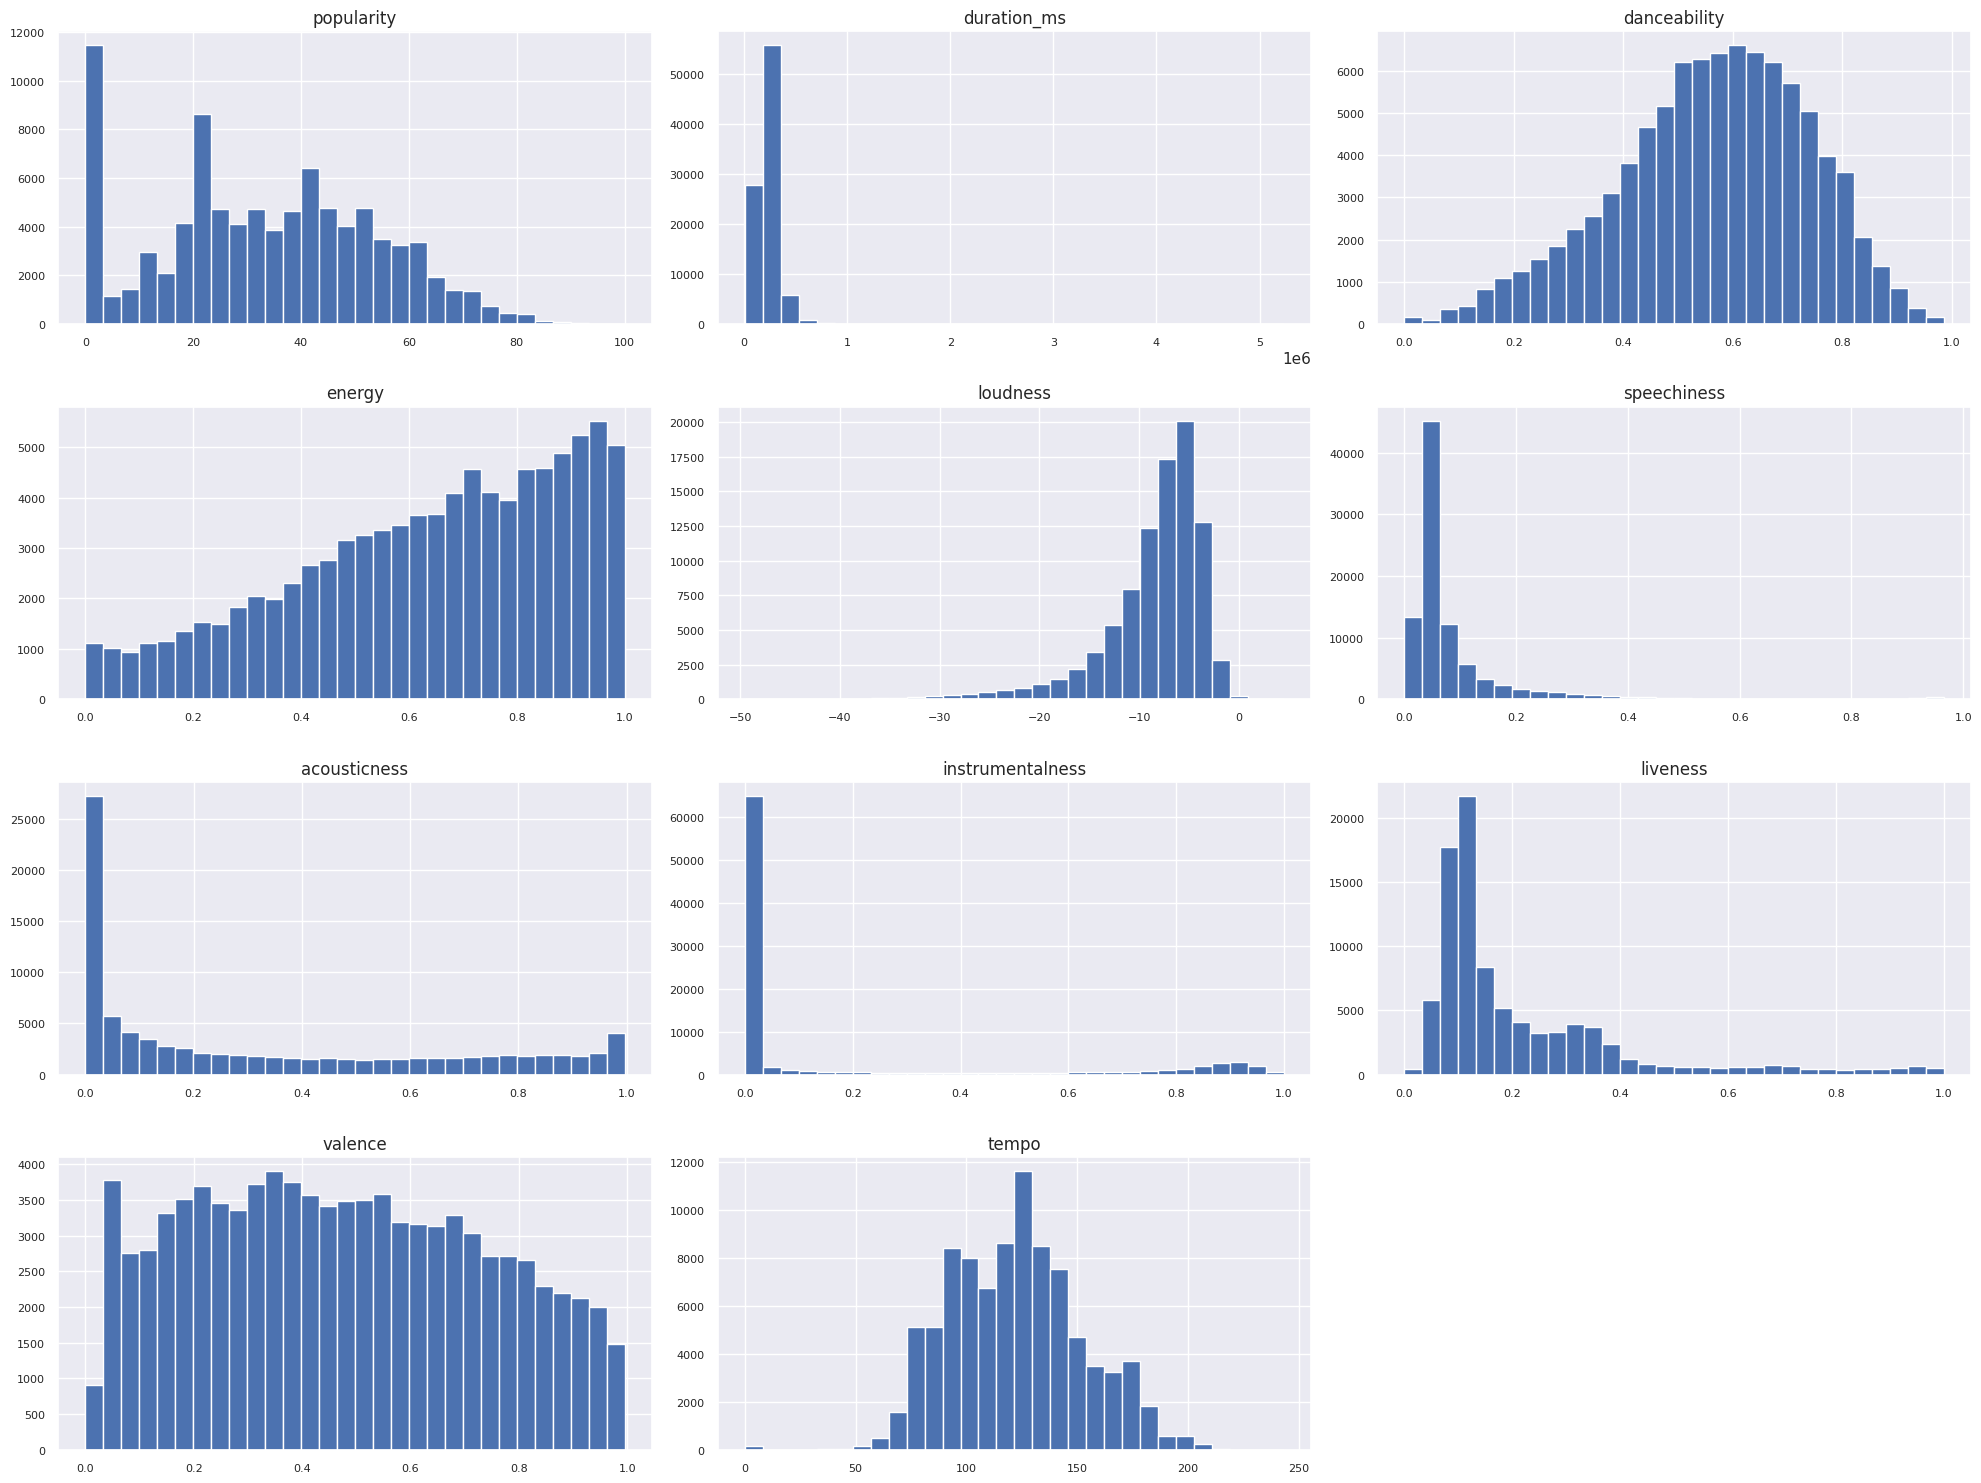

In [8]:
sns.set()
df[prop_acusticas].hist(figsize=(20,15), bins=30, xlabelsize=8, ylabelsize=8)
plt.tight_layout()
plt.show()

In [9]:
df.sort_values("popularity", ascending=False)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance
51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop
20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,dance
67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latin
67359,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,False,0.650,0.715,5,-5.198,0,0.2530,0.09930,0.000291,0.1260,0.187,106.672,4,latin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67728,3AVpTpnfKlzxeDKZHUauUq,Mariah Angeliq;Lele Pons,Esto me suena a Farra,Sucio Y Lento,0,222386,False,0.717,0.758,5,-2.367,0,0.0718,0.37000,0.000303,0.0861,0.960,175.951,4,latin
67740,5HpivGfblVhlWwNTvmyzHL,Mariah Angeliq,La navidad es todo aquello que nos hace record...,Last Christmas,0,217893,False,0.745,0.812,0,-5.770,1,0.0254,0.09540,0.000000,0.0473,0.968,112.026,4,latin
67741,3sdYKmzjWTanqTJuyf0GAf,Mariah Angeliq;Guaynaa,Noche de Halloween Latino,Taxi,0,173653,False,0.727,0.796,7,-3.918,0,0.1250,0.06270,0.000000,0.1660,0.701,180.069,4,latin
67742,3WNYZX9nMweT6S3s7BrEQ7,Thalia,Halloween 2022 Pop Vol. 4,Mujer Latina,0,218333,False,0.799,0.966,8,-5.408,0,0.0877,0.17000,0.000022,0.1980,0.961,126.839,4,latin


## Prep 4: Normaliza las variables de propiedades acústicas
Hazlo en un dataframe a parte "df_acust" que contenga el track_id como índice.

In [10]:
df_acust = df[prop_acusticas]
df_acust.index = df["track_id"]
df_acust = (df_acust - df_acust.mean()) / df_acust.std()
df_acust.sample(10)

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
track_id,,,,,,,,,,,
4U45aEWtQhrm8A5mxPaFZ7,2.172389,-0.132086,-0.172735,-0.545506,0.350992,-0.469452,0.980247,-0.534517,-0.726432,-0.615741,0.094985
1sl6EiHX5lJPfdZZKDnxD9,1.056303,-0.628751,-0.348319,1.397379,0.573668,-0.063384,-0.955306,2.254569,-0.359337,-0.071578,0.928922
53u6z4AWKeb5rJCJ45Q3P5,0.182844,0.319895,-0.314335,-0.022721,-0.300336,0.025968,-0.667548,2.041213,-0.608510,-1.262648,0.762294
40RKZ0dDeEx2srKcAznvrf,0.619573,1.718483,0.852449,-0.260705,0.846638,0.359492,-0.808069,-0.534491,-0.200399,0.754179,-0.543967
7y4XcoRcRDFnVltwFp2XAm,-0.545038,0.609227,0.903425,0.972129,0.672144,1.368026,-0.817536,-0.534517,-0.677212,0.012139,1.256102
7fRvtXvJMpGfTLdF0M09a1,1.590083,0.052870,0.892097,1.295943,0.778683,-0.469452,-0.883803,-0.533450,-0.384972,1.930027,0.255370
6zvaZ4TbFRvni9LYJG6QHh,-0.496513,-0.366010,0.897761,-0.003214,-0.428183,-0.460605,-0.745944,-0.534500,-0.564418,1.248872,0.696579
0rGllPwXKYxS07xZ0osn22,-0.787666,2.135545,-1.299871,-1.001966,-1.504131,-0.294285,0.551288,2.279306,-0.688492,-1.525596,1.591151
55ZCkYWwgwFAxLHB79DgYf,1.153354,0.021490,-0.540895,-0.709363,0.074182,-0.414602,1.083789,-0.534517,-0.543910,-0.870699,0.439199


In [11]:
df_acust.describe()

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,9.046000e+04,9.046000e+04,9.046000e+04,9.046000e+04,9.046000e+04,9.046000e+04,9.046000e+04,9.046000e+04,9.046000e+04,9.046000e+04,9.046000e+04
mean,2.702042e-17,-1.244196e-16,1.005411e-17,-1.699773e-16,1.432711e-16,-1.303892e-16,-9.944142e-17,3.035870e-17,-1.900855e-16,2.482108e-16,2.171059e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.612599e+00,-1.956135e+00,-3.185983e+00,-2.476686e+00,-7.878234e+00,-7.728968e-01,-9.692989e-01,-5.345166e-01,-1.113009e+00,-1.787784e+00,-4.053649e+00
25%,-6.906149e-01,-4.974606e-01,-6.371833e-01,-6.898565e-01,-3.496701e-01,-4.544124e-01,-9.187112e-01,-5.345166e-01,-6.095354e-01,-8.364505e-01,-7.573238e-01
50%,-1.125806e-02,-1.404852e-01,7.648060e-02,1.645447e-01,2.511714e-01,-3.398464e-01,-4.160893e-01,-5.343379e-01,-4.362420e-01,-4.494113e-02,-1.943745e-03
75%,7.651497e-01,3.113894e-01,7.335045e-01,8.511867e-01,6.494929e-01,-1.384221e-02,8.767053e-01,-2.395291e-01,3.174305e-01,8.112589e-01,5.978576e-01
max,3.239950e+00,4.441992e+01,2.393056e+00,1.424689e+00,2.499816e+00,7.764256e+00,1.977208e+00,2.557596e+00,4.014015e+00,1.998523e+00,4.027779e+00


<Axes: >

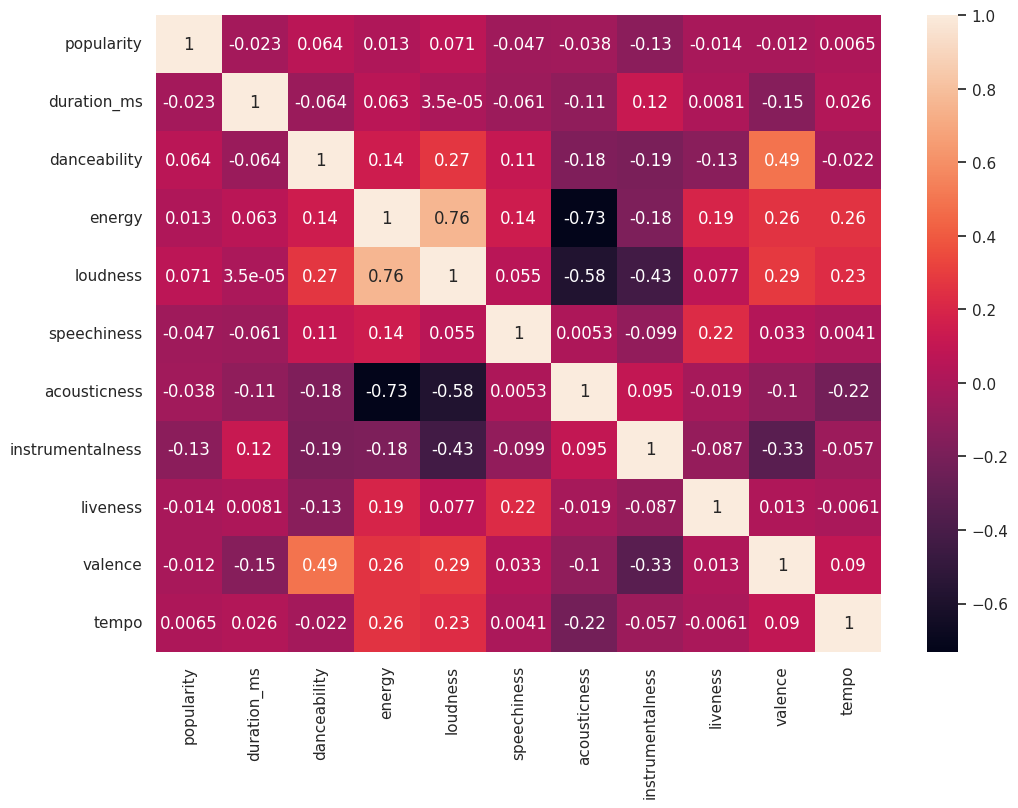

In [12]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.heatmap(df_acust.corr(), annot=True)

In [13]:
# Prepare an empty list to collect results
rows = []
for col in prop_acusticas:
    min_idx = df[col].idxmin()
    max_idx = df[col].idxmax()
    min_val = f"https://open.spotify.com/track/{df.loc[min_idx,'track_id']}"
    max_val = f"https://open.spotify.com/track/{df.loc[max_idx, 'track_id']}"
    rows.append({'Column': col, 'Max Song': max_val, 'Min Song': min_val})

# Create the final table
result_df = pd.DataFrame(rows)

result_df

,Column,Max Song,Min Song
0,popularity,https://open.spotify.com/track/3nqQXoyQOWXiESF...,https://open.spotify.com/track/0BUuuEvNa5T4lMa...
1,duration_ms,https://open.spotify.com/track/3Cnz3Bu9Wcw8p3k...,https://open.spotify.com/track/6hsyfegVY5yklJn...
2,danceability,https://open.spotify.com/track/4xKKIS9g9nivSiE...,https://open.spotify.com/track/59gg6zQhSKGVnkT...
3,energy,https://open.spotify.com/track/0iW6j69kd9YJSM6...,https://open.spotify.com/track/3gIEb1mxGFTMlJA...
4,loudness,https://open.spotify.com/track/0HfHtjS9S9q4DGV...,https://open.spotify.com/track/5utUKeJ2ZG9KCZb...
5,speechiness,https://open.spotify.com/track/5j7NfGi2DdRJU6Z...,https://open.spotify.com/track/59gg6zQhSKGVnkT...
6,acousticness,https://open.spotify.com/track/3KG9I4JXpDwNQOs...,https://open.spotify.com/track/0GxyutETmsiOx8k...
7,instrumentalness,https://open.spotify.com/track/5UBonaClAZVfzxJ...,https://open.spotify.com/track/1iJBSr7s7jYXzM8...
8,liveness,https://open.spotify.com/track/2tFltPmM99c66qj...,https://open.spotify.com/track/3gIEb1mxGFTMlJA...
9,valence,https://open.spotify.com/track/1QGpYmCjN9Jp4MG...,https://open.spotify.com/track/59gg6zQhSKGVnkT...


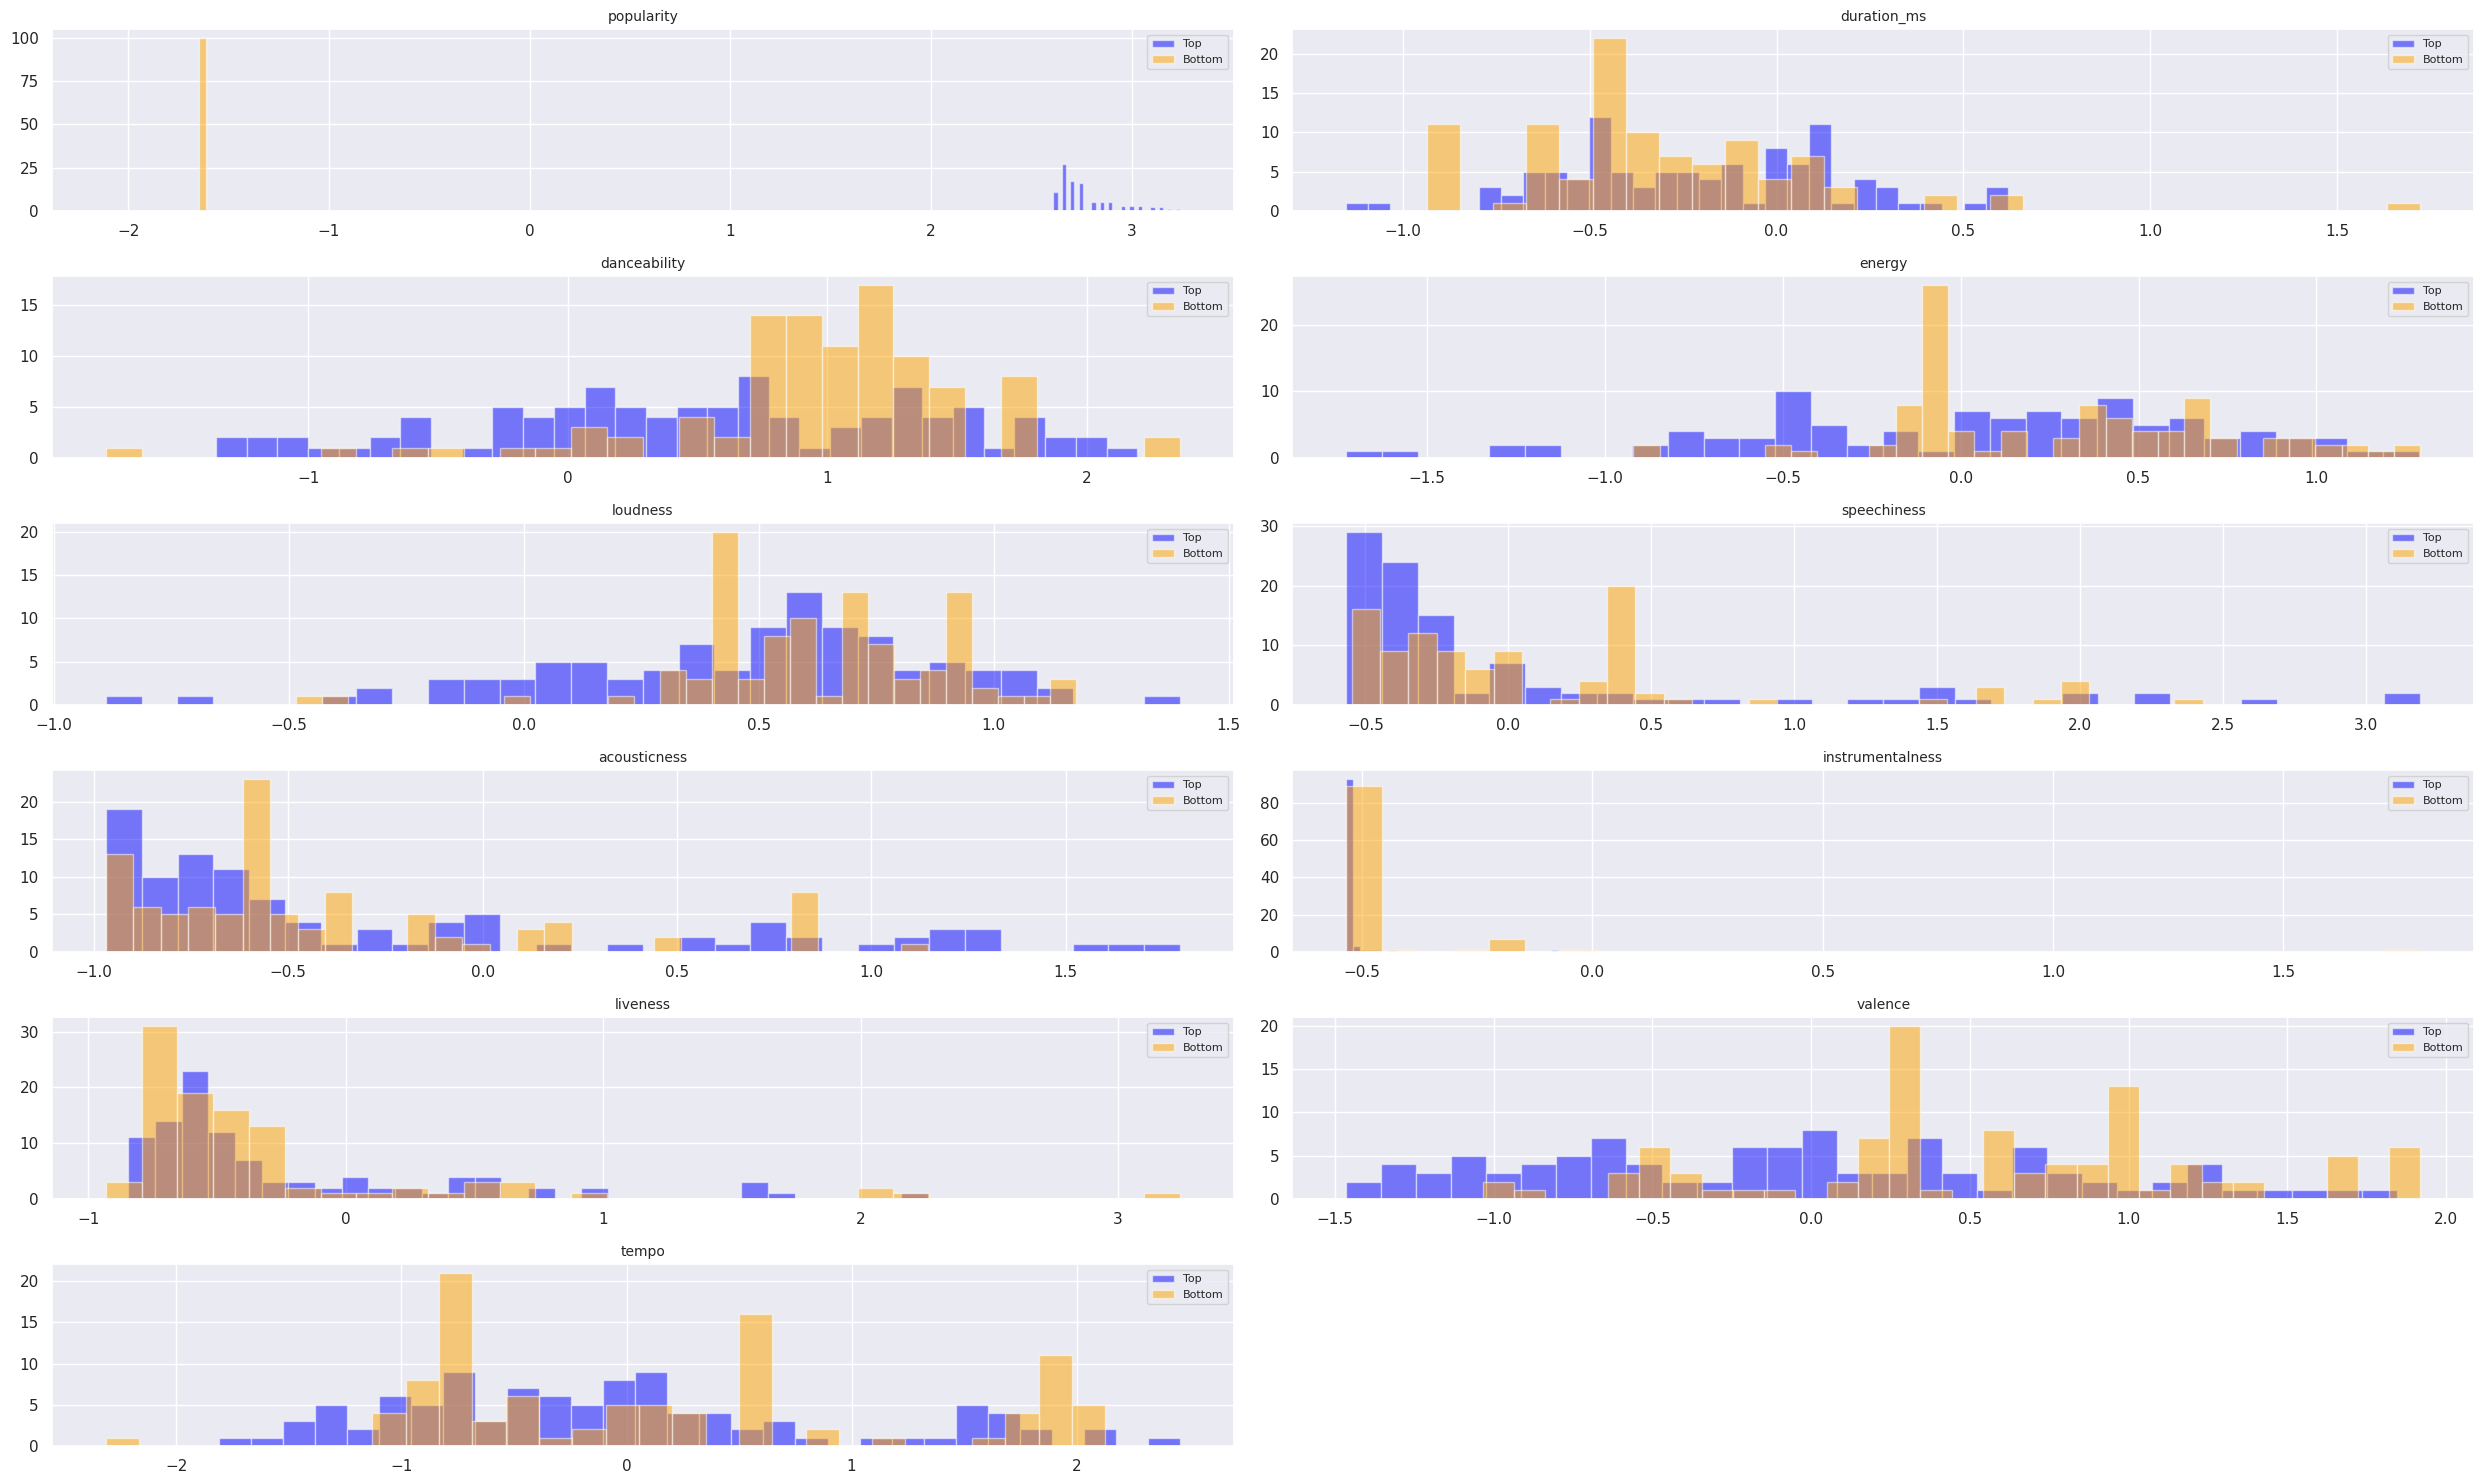

In [14]:
filter_top = df_acust.index.isin(list(df_acust.sort_values("popularity", ascending=False).head(100).index))
filter_bottom = df_acust.index.isin(list(df_acust.sort_values("popularity", ascending=False).tail(100).index))

cols = df_acust[prop_acusticas].columns
n_cols = 2  # adjust number of columns in the subplot grid
n_rows = -(-len(cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    df_acust[filter_top][col].plot(kind='hist', bins=30, alpha=0.5, color='blue', label='Top', ax=ax)
    df_acust[filter_bottom][col].plot(kind='hist', bins=30, alpha=0.5, color='orange', label='Bottom', ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(fontsize=8)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Podemos ver que hay cierta estructura interna en el dataset:

- Energy, Loudness correclaciona negativamente con acousticness
- Energy, Loudness y (un poco) de valence y tempo correlacionan: las canciones energéticas tienen volumen alto, suelen ser más "positivas" y con un ritmo/tempo más alto.

Podemos usarlo para KMeans, pero si encontráis un dataset con **muchas** correlaciones y estructura interna a veces **se recomienda reducir la dimensionalidad (p.e.: PCA) antes de un clustering**.

# Ejercicio 1: intuición sobre el clustering de Spotify

En este primer ejercicio queremos comenzar a familiarizarnos con el dataset: qué tipo de clusters aparecen, si estos tienen sentido o no, qué variables son importantes o no...

- Crea clusters en el dataset, aún no uses el método del codo.
- Simplemente haz varias pruebas: cambia el número de clusters, quita o añade variables, usa un PCA, etc.
- Intenta obtener una intuición de los clusters: escucha canciones de un mismo cluster, haz análisis descriptivo de cada cluster (¿Cuál es la media de tempo? ¿su distribución? ¿Qué canciones hay?)
- Puedes ver el resto de variables del dataset en `df`, además recuerda que con el trackID puedes escucharla en Spotify si la copias en la barra de búsqueda así: `spotify:track:4qPNDBW1i3p13qLCt0Ki3A`

In [15]:
df.shape

(90460, 20)

In [16]:
from sklearn.cluster import KMeans

In [17]:
kmeans = KMeans(n_clusters=50)
kmeans.fit(df_acust)

KMeans(n_clusters=50)

In [18]:
df_with_clusters = df
df_with_clusters["cluster"] = kmeans.labels_
df_with_clusters.sample(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster
54748,75l2tm5fwgY75Yscjxd1Xd,Datassette,Selected Offal,Vocoder Mic Tap Loop Verb,11,70197,False,0.700,0.242,0,...,0,0.0395,0.9960,0.940000,0.1550,0.586,95.759,4,idm,27
98388,76M8AXFxBcmXxrJIPcIDZX,25th Annual Putnam County Spelling Bee Origina...,25th Annual Putnam County Spelling Bee (Origin...,Finale,26,61480,False,0.637,0.387,0,...,1,0.0372,0.7570,0.000000,0.2670,0.881,83.271,4,show-tunes,39
38001,5FVd6KXrgO9B3JPmC8OPst,Arctic Monkeys,AM,Do I Wanna Know?,88,272394,False,0.548,0.532,5,...,1,0.0323,0.1860,0.000263,0.2170,0.405,85.030,4,garage,4
2632,0HdKT77fmQMoU0mAjHs7O0,Atreyu,Release Your ANGER,Anger Left Behind,0,203547,False,0.418,0.987,0,...,1,0.2090,0.0585,0.000144,0.0855,0.250,155.050,4,alt-rock,18
18400,1JT55KoXuhtYy5BeKNAeC0,The Lonely Island;Rihanna,Turtleneck & Chain (Explicit Version),Shy Ronnie 2: Ronnie & Clyde,49,146506,True,0.623,0.770,6,...,0,0.2080,0.0025,0.000000,0.2950,0.248,150.002,4,comedy,1


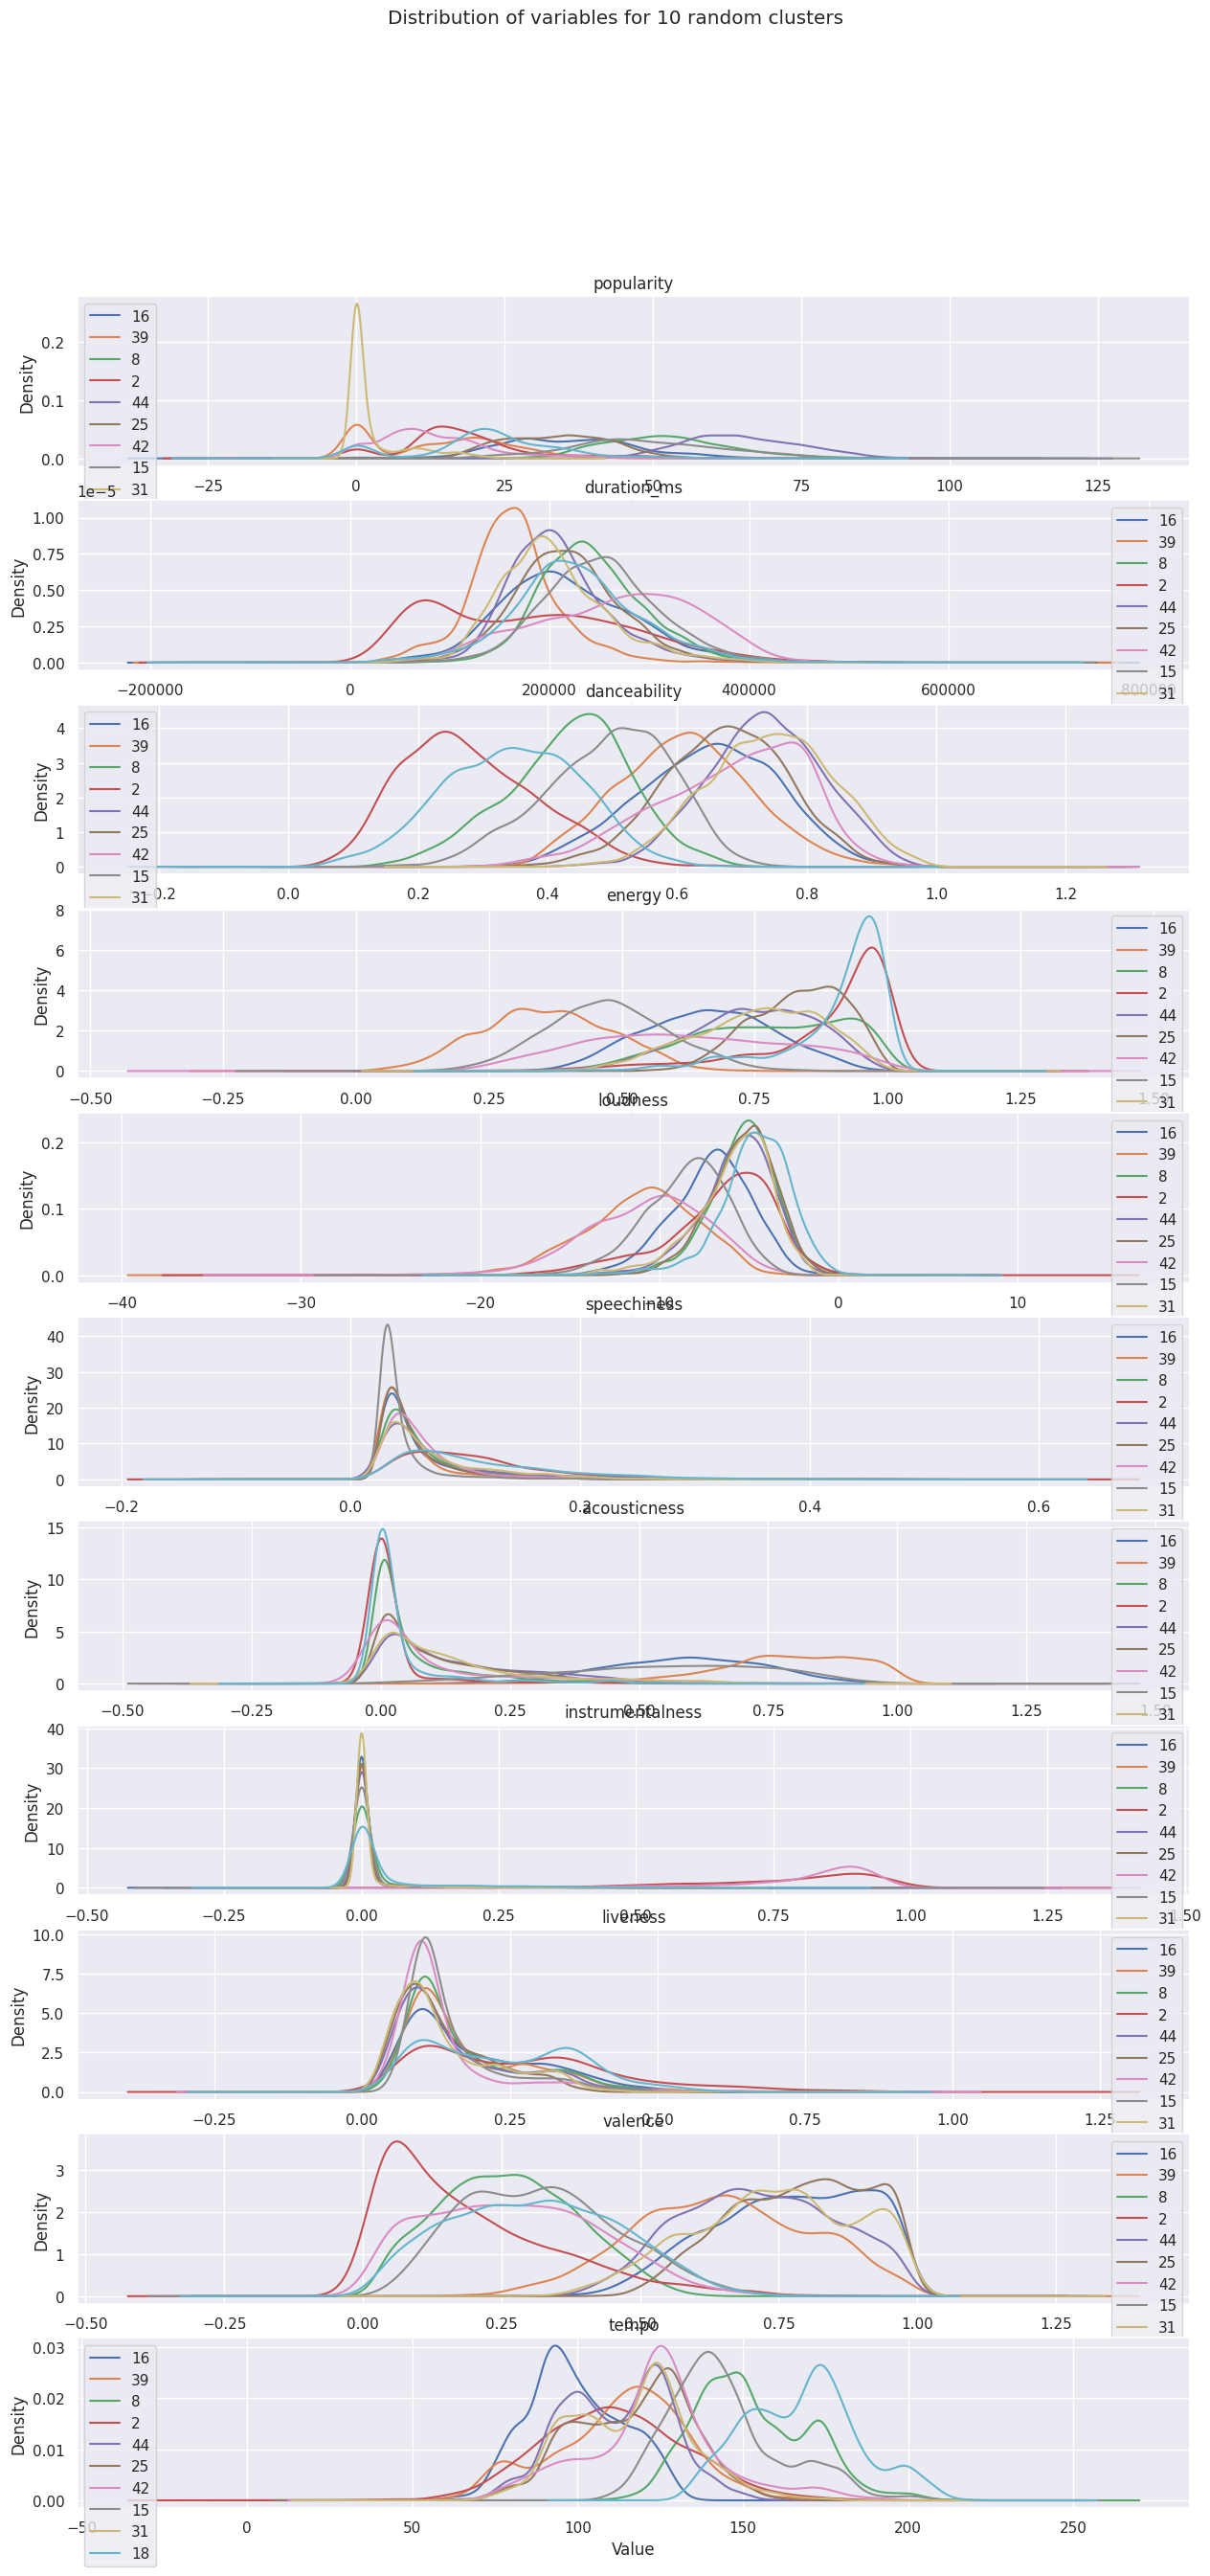

In [19]:
# prompt: generate distribution plots to compare 10 random picked clusters among all variables.
# Make it interactive so I can hover the lines and use a categorical scale for the coloring.

import seaborn as sns
import matplotlib.pyplot as plt

# Select 10 random clusters
clusters = df_with_clusters['cluster'].sample(10)

# Create a list of subplots
fig, axes = plt.subplots(nrows=len(prop_acusticas), ncols=1, figsize=(15, 30))

# Iterate through each variable and plot the distribution for each cluster
for i, variable in enumerate(prop_acusticas):
    ax = axes[i]
    for cluster in clusters:
        df_with_clusters[df_with_clusters['cluster'] == cluster][variable].plot(kind='kde', ax=ax, label=cluster)
    ax.set_title(variable)
    ax.legend()
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')

# Set the overall figure title
fig.suptitle('Distribution of variables for 10 random clusters')

# Show the plot
plt.show()


In [20]:
# Voy a observar el cluster 39

In [21]:
df_with_clusters[df_with_clusters.cluster == 39]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster
23,0BUuuEvNa5T4lMaewyiudB,Jason Mraz,Coffee Moment,93 Million Miles,0,216386,False,0.572,0.454,3,...,1,0.0258,0.477,0.000014,0.0974,0.515,140.182,4,acoustic,39
25,6D33wCKzWtNEgOovgeVJ7r,Jason Mraz,Mellow Adult Pop,Bella Luna,1,302346,False,0.755,0.454,9,...,0,0.0352,0.757,0.000000,0.2360,0.330,120.060,4,acoustic,39
26,5IfCZDRXZrqZSm8AwE44PG,Jason Mraz,Holly Jolly Christmas,Winter Wonderland,0,131760,False,0.620,0.309,5,...,1,0.0495,0.788,0.000000,0.1460,0.664,145.363,4,acoustic,39
28,5QAMZTM5cmLg3fHX9ZbTZi,Jason Mraz,Christmas Time,Winter Wonderland,0,131760,False,0.620,0.309,5,...,1,0.0495,0.788,0.000000,0.1460,0.664,145.363,4,acoustic,39
29,2qESE1ZeWly7I3YjyTXmXh,Jason Mraz,Perfect Christmas Hits,Winter Wonderland,0,131760,False,0.620,0.309,5,...,1,0.0495,0.788,0.000000,0.1460,0.664,145.363,4,acoustic,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113804,11TMcTS3iao1dvMogUSQVk,Buena Vista Social Club,Buena Vista Social Club,De Camino a la Vereda,11,303973,False,0.630,0.462,3,...,1,0.0406,0.849,0.000186,0.1250,0.963,84.252,4,world-music,39
113849,0hydAWLokpunNzzBUXNe0U,Cesária Evora,Best Of,Tudo Tem Se Limite,23,272600,False,0.641,0.306,7,...,0,0.0940,0.867,0.000000,0.3410,0.746,77.944,4,world-music,39
113867,4cirFEQ9qFi9C5Iy0uSwGM,Cesária Evora,The Very Best Of,Petit pays,23,224533,False,0.581,0.427,4,...,0,0.0354,0.796,0.000000,0.2820,0.864,77.895,4,world-music,39
113949,1wLWY9NxvVh3AIw78hvRGe,Cesária Evora,Best Of,Sabine Larga’m,23,188917,False,0.546,0.463,9,...,0,0.0404,0.432,0.000022,0.3730,0.487,127.358,4,world-music,39


Examples of songs in cluster 39:
52877. As Long As I Live by George Jones (https://open.spotify.com/track/13q0ucz92ohuhFsHG8Gfqt)
26881. Scare Me Music by George Bruns (https://open.spotify.com/track/3kIe1EWcFkiiicVJrPqB20)
93529. Druzhba by Vadim Kozin (https://open.spotify.com/track/5H5woTnlQSsZoUphtm3WZW)
12100. 多情 by Vivian Lai (https://open.spotify.com/track/7G3SiHyxhJ2pm1oewL1GDG)
52789. Heartaches By The Number by Ray Price (https://open.spotify.com/track/50LnjReEjYeVSZY2NGoK6e)

Genre frequency table:
track_genre
honky-tonk    470
tango         440
jazz          204
romance       197
blues         127
             ... 
dancehall       1
forro           1
punk-rock       1
reggaeton       1
techno          1
Name: count, Length: 81, dtype: int64


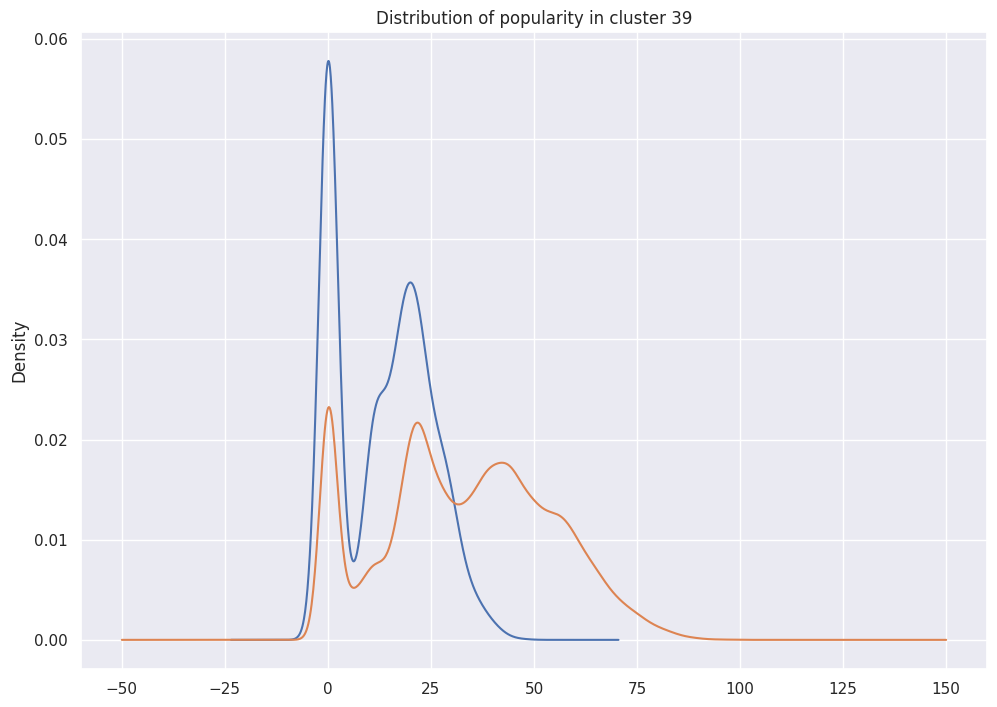

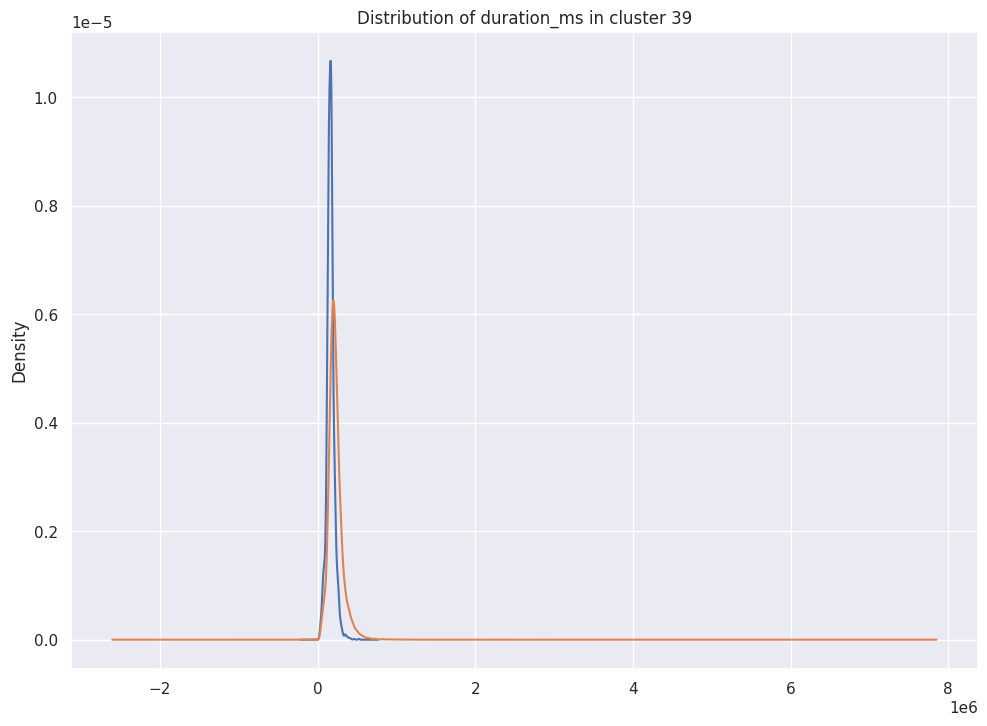

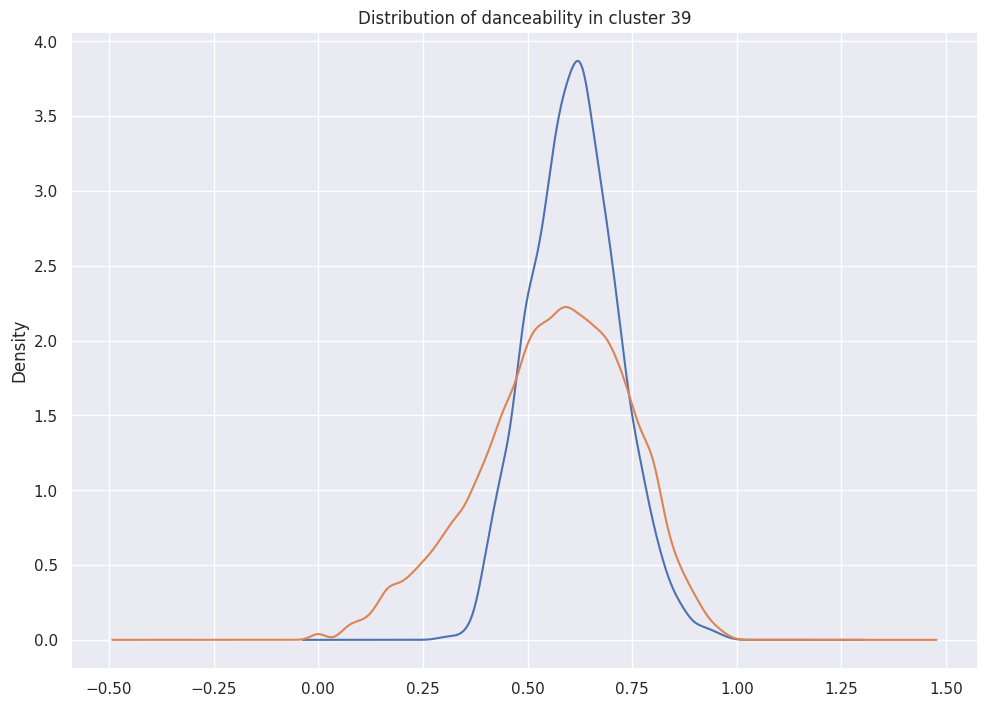

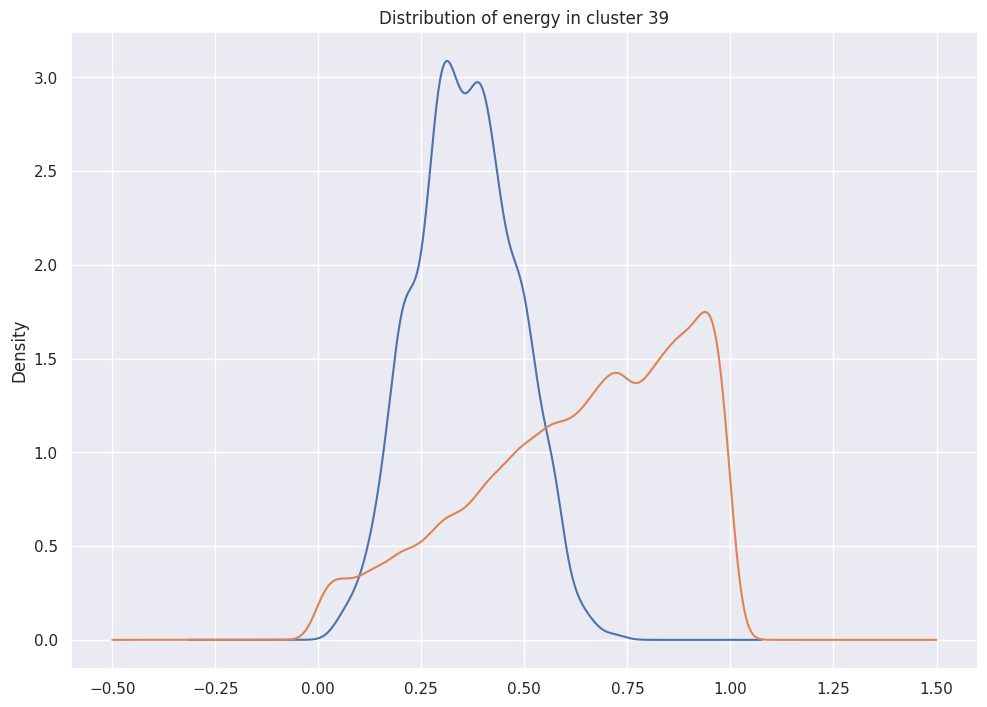

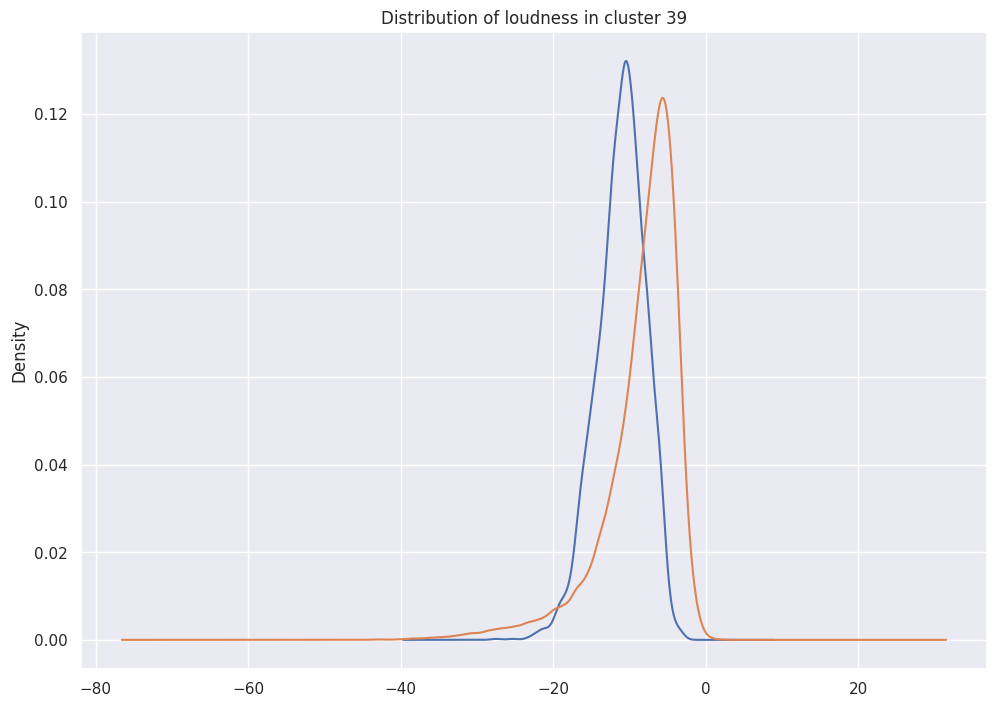

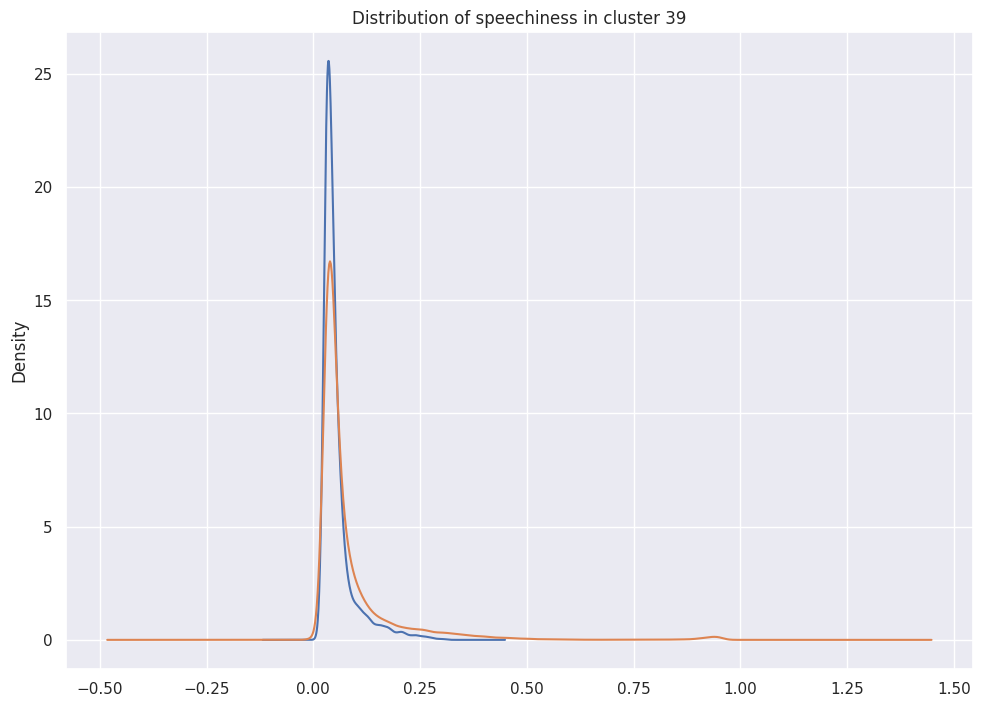

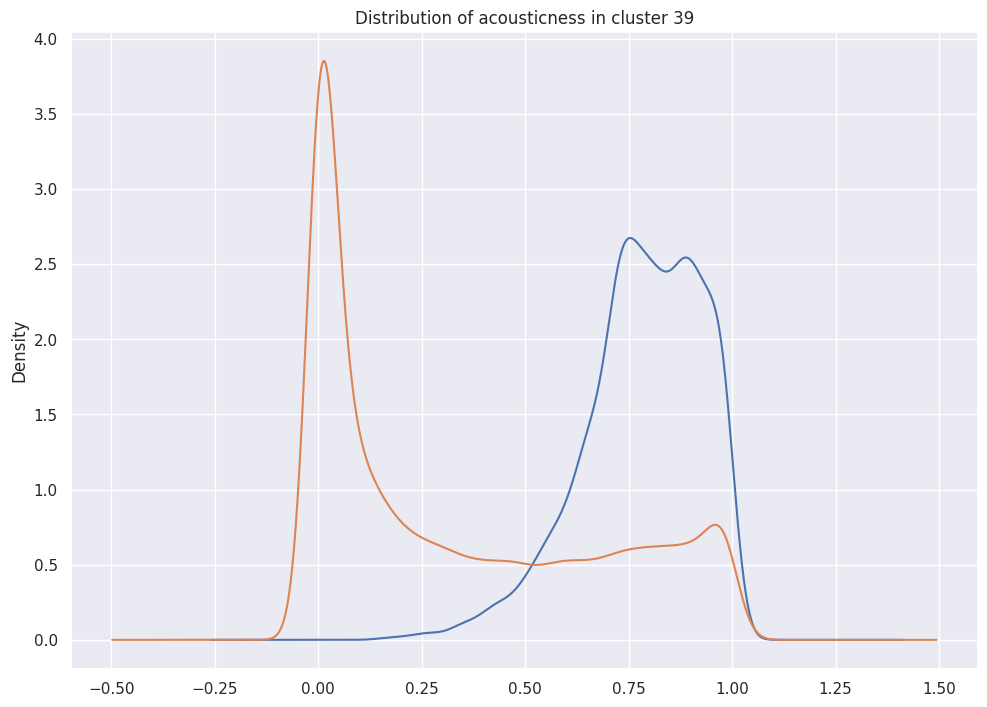

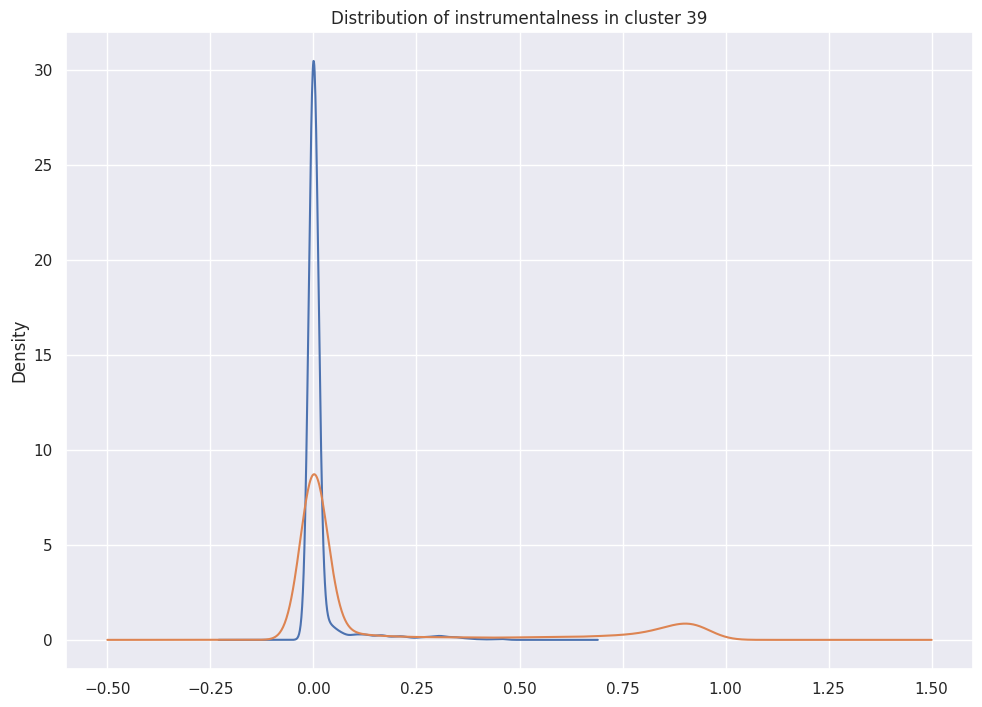

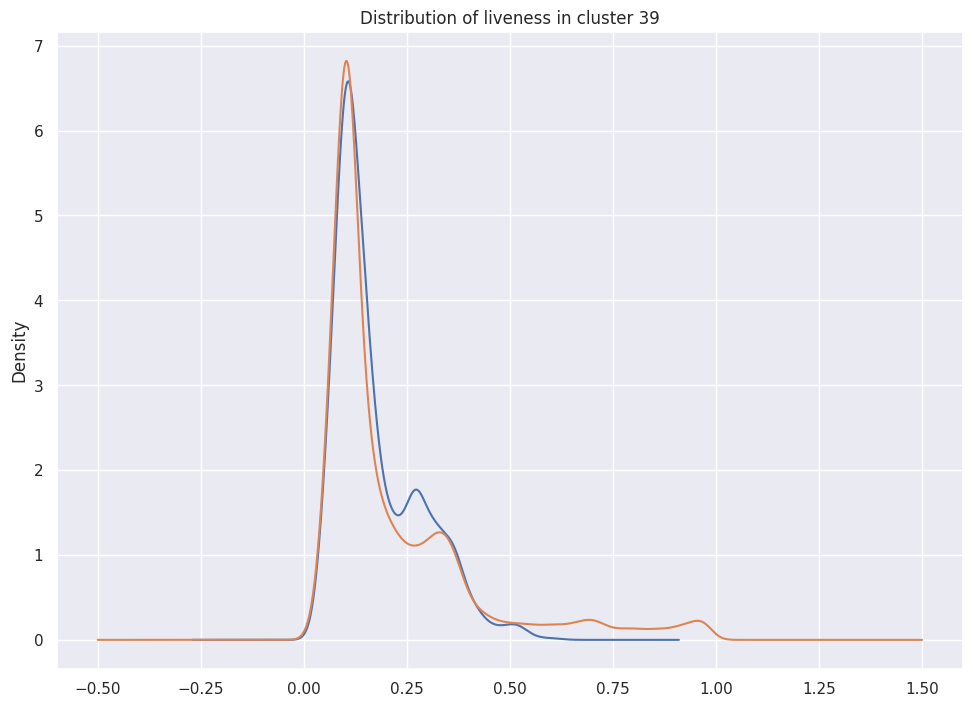

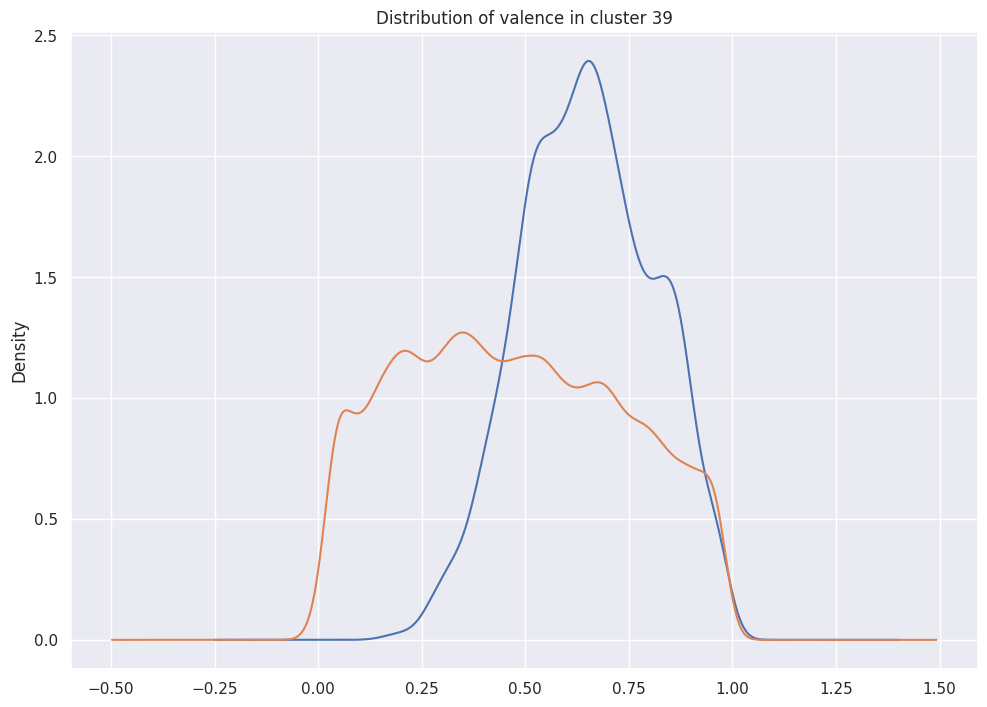

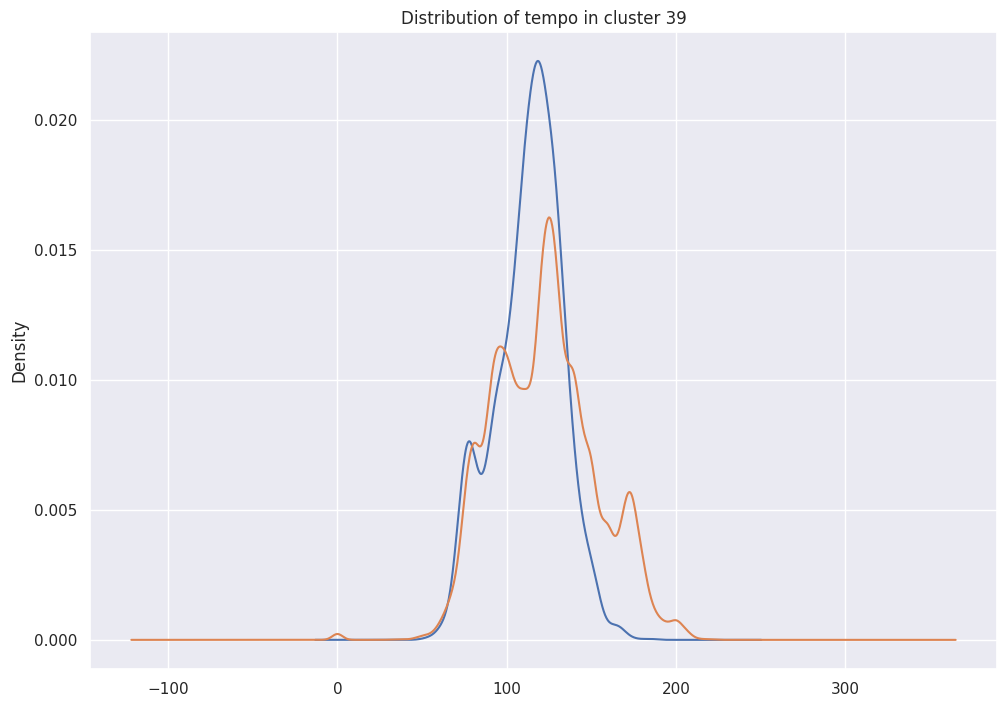

In [22]:
# prompt: Analyze cluster 39. Extract some examples. use the trackid to create SPOTIFY URLS to listen the song, show the genre fecuency table and the distribution of the variables.

import matplotlib.pyplot as plt
cluster_39 = df_with_clusters[df_with_clusters['cluster'] == 39]

# Extract some examples
examples = cluster_39.sample(5)
print("Examples of songs in cluster 39:")
for i, row in examples.iterrows():
  track_id = row['track_id']
  title = row['track_name']
  artist = row['artists']
  url = f"https://open.spotify.com/track/{track_id}"
  print(f"{i+1}. {title} by {artist} ({url})")

# Show the genre frequency table
genre_counts = cluster_39['track_genre'].value_counts()
print("\nGenre frequency table:")
print(genre_counts)

# Show the distribution of the variables
for variable in prop_acusticas:
  plt.figure()
  cluster_39[variable].plot(kind='kde')
  df[variable].plot(kind='kde')
  plt.title(f"Distribution of {variable} in cluster 39")
  plt.show()


Examples of songs in cluster 39:
42071. Alienate by Fluoride (https://open.spotify.com/track/0uQjcHmUqkKdPiDPYsylm1)
42653. The Prophets of Loss by Cattle Decapitation (https://open.spotify.com/track/2mgMvzLrnzvh9AwFhOxtvE)
42213. Coagulative Necrosis by Last Days Of Humanity (https://open.spotify.com/track/7uI6dvHU3zdSdtkbC3BCku)
4703. Reminiscence by aswekeepsearching (https://open.spotify.com/track/5gQwnCbHVKuDFTtjkHZPGT)
42455. Present Day by Vermin Womb (https://open.spotify.com/track/5fXQtkXisWh8zkJ2vIOXY9)

Genre frequency table:
track_genre
grindcore            553
black-metal          207
death-metal          138
iranian              121
sleep                 35
garage                31
idm                   28
british               23
club                  21
trance                19
industrial            19
heavy-metal           16
power-pop             16
happy                 15
anime                 15
drum-and-bass         13
breakbeat             11
goth                

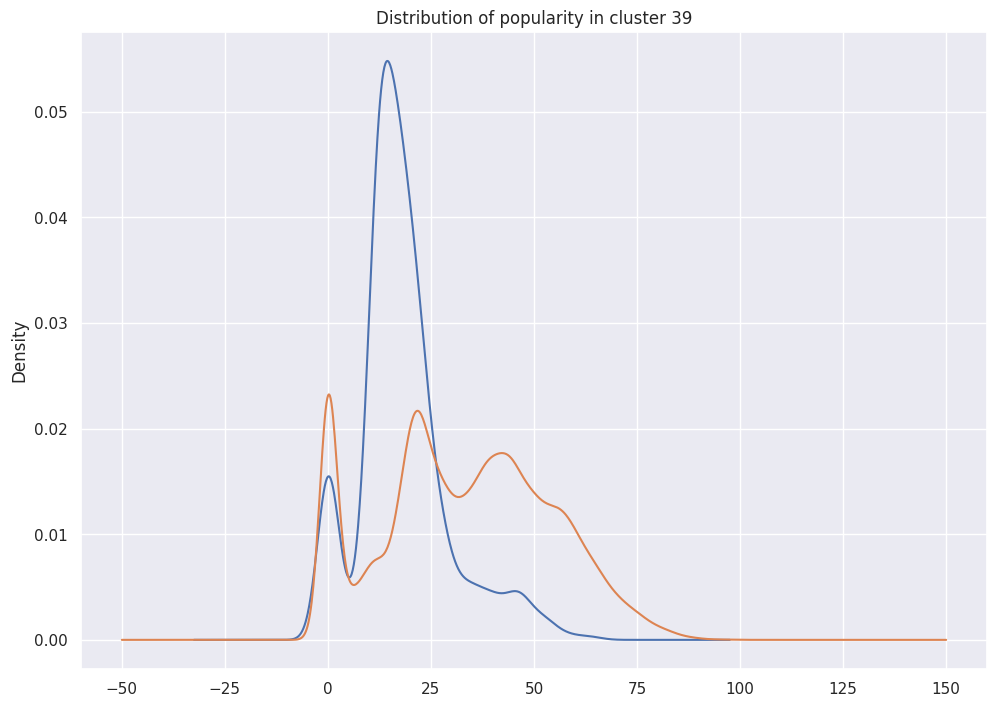

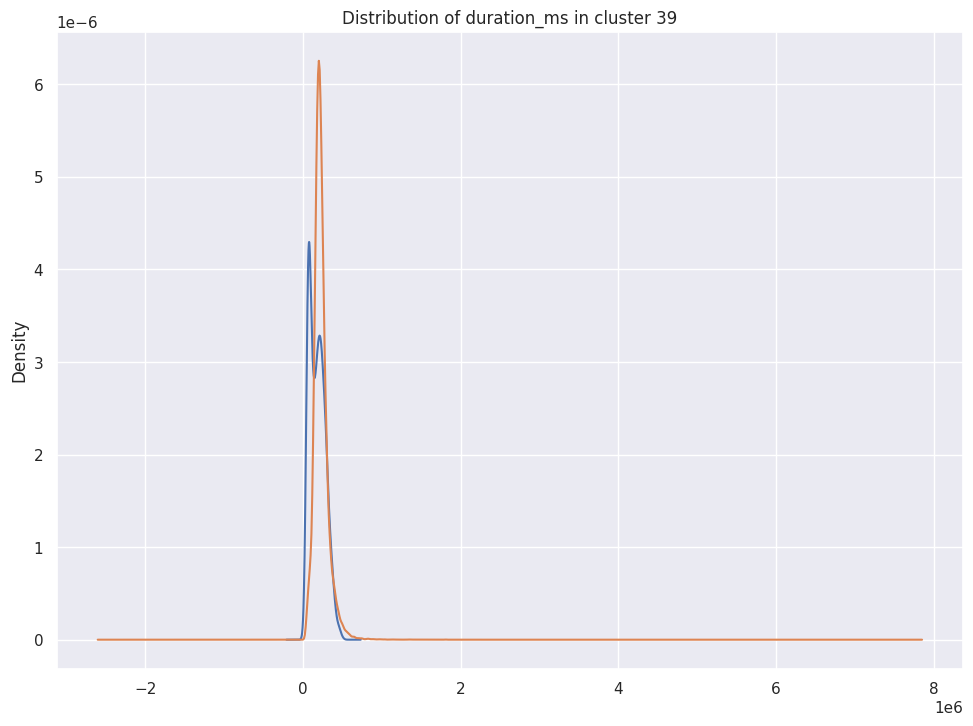

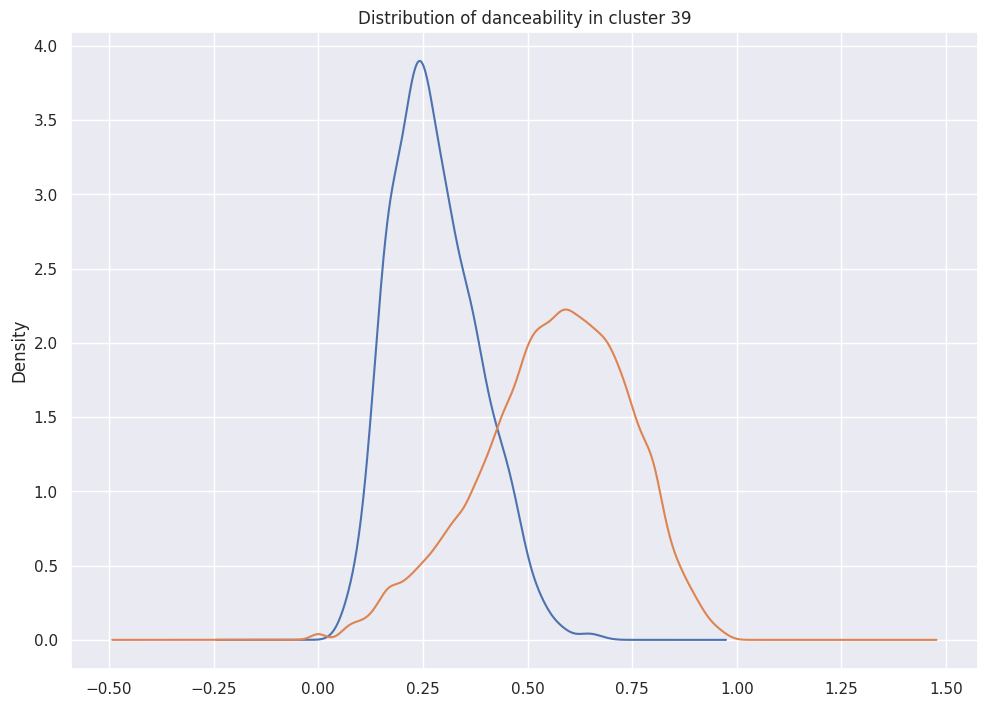

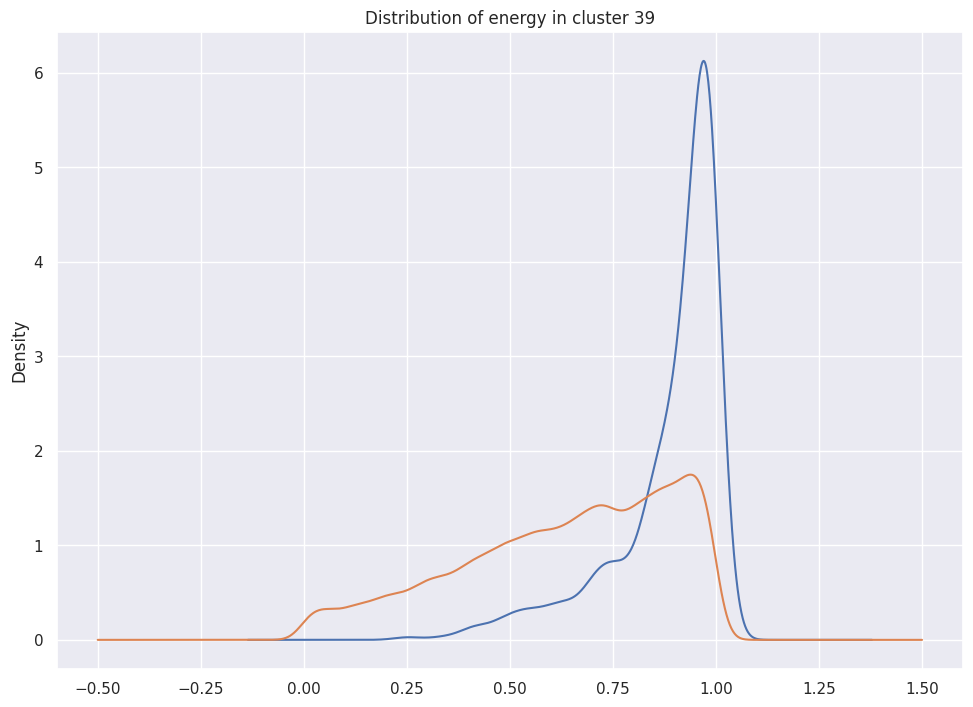

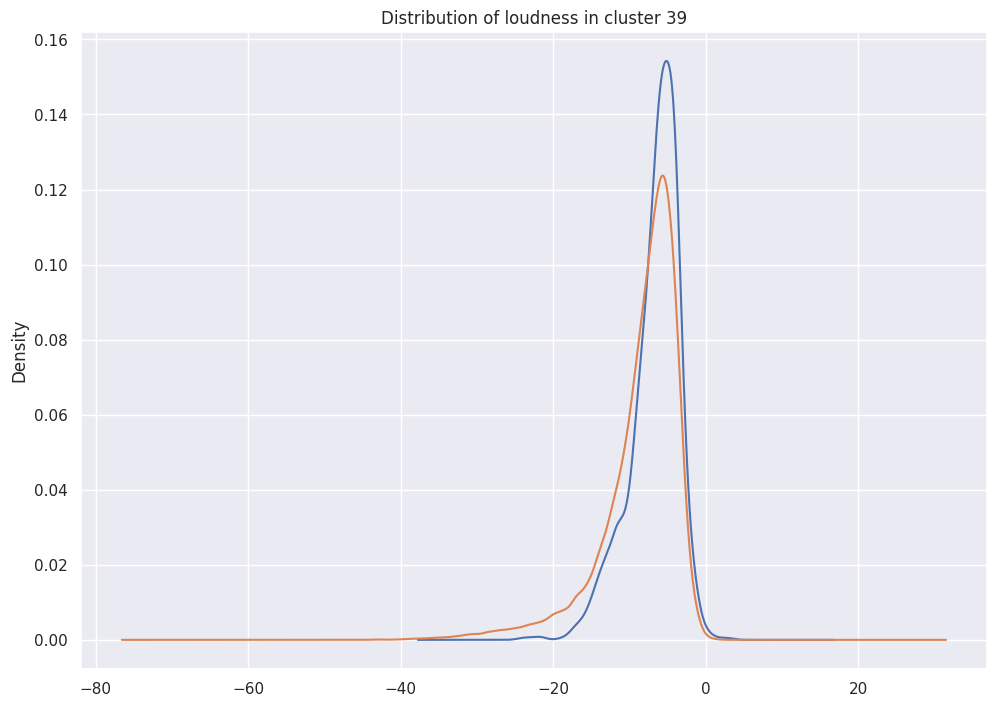

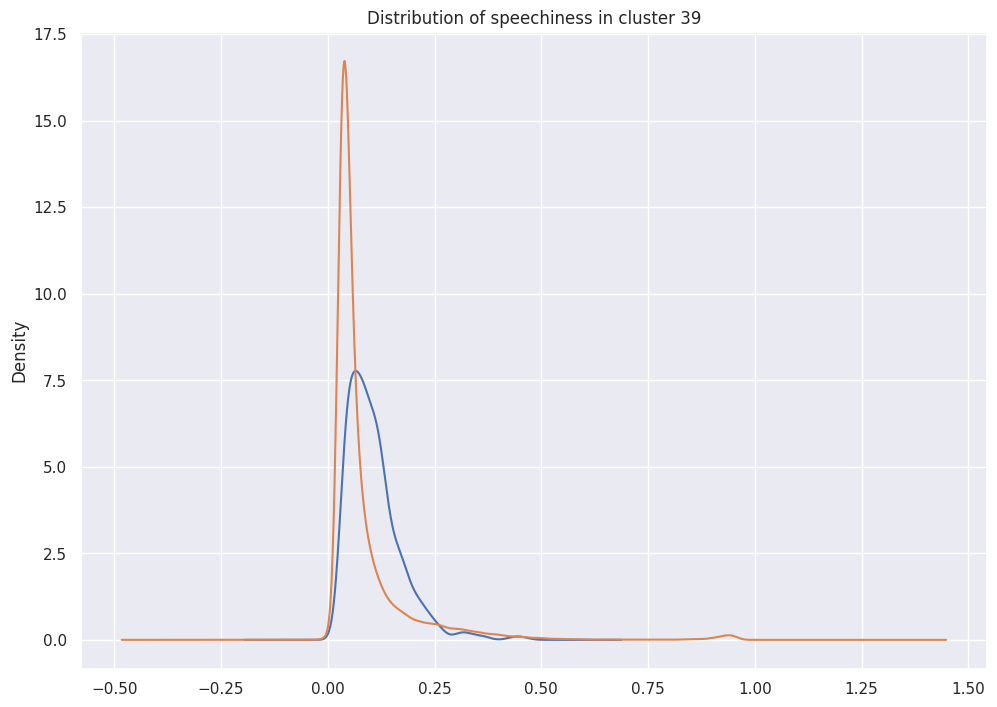

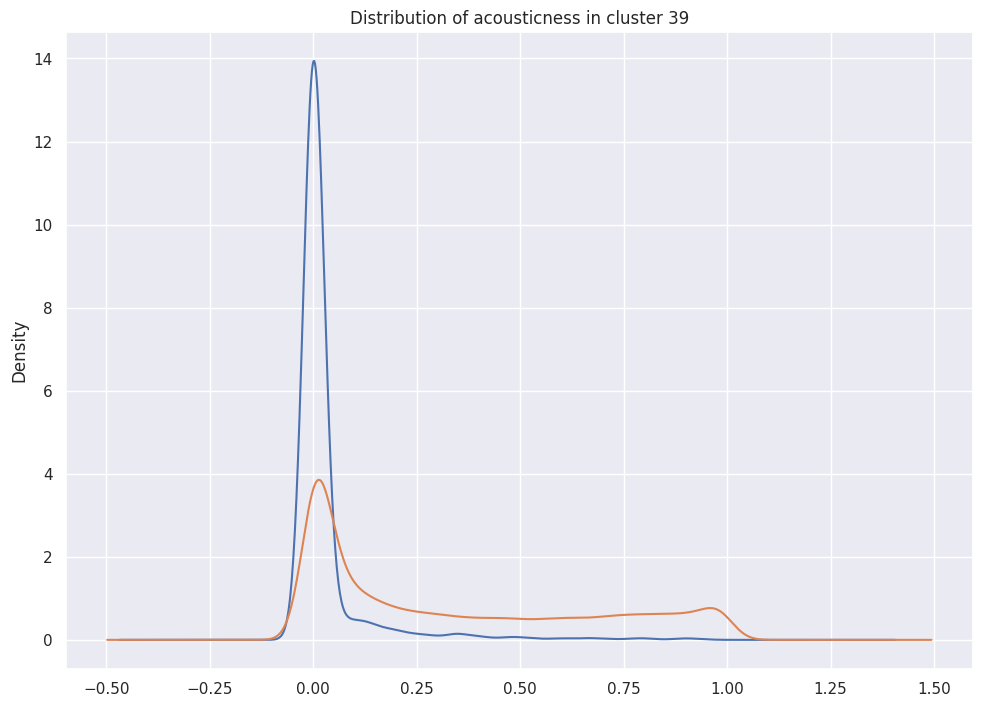

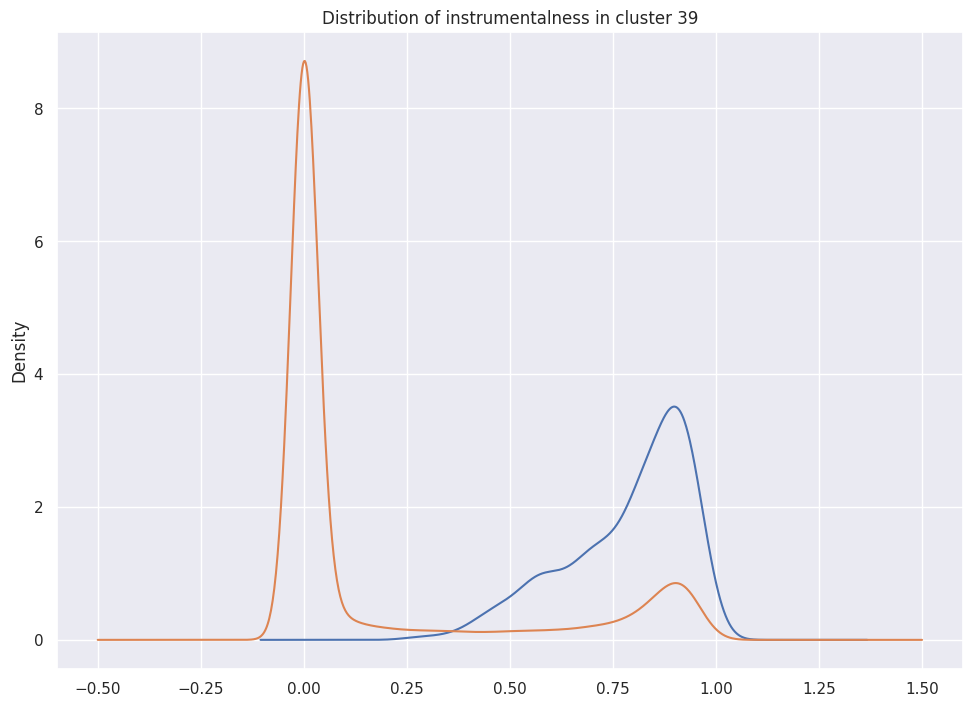

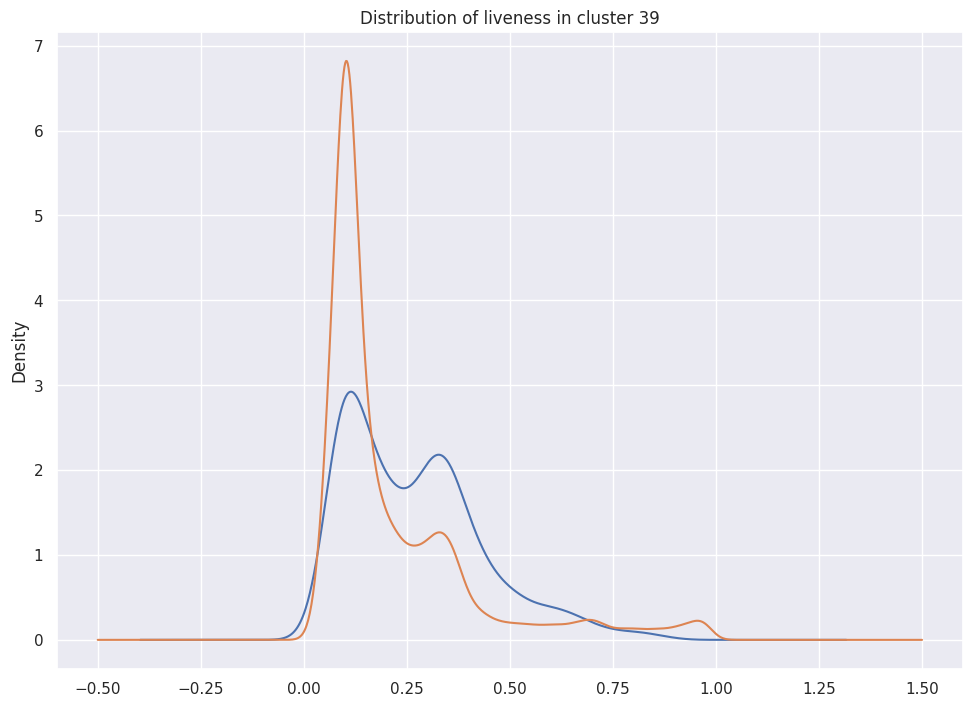

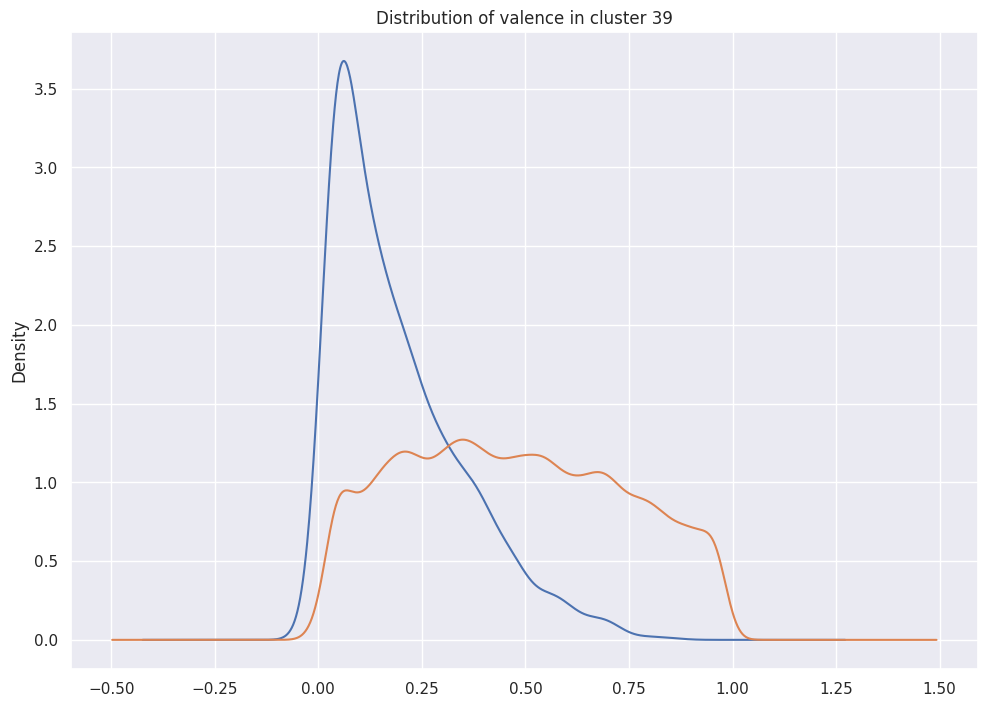

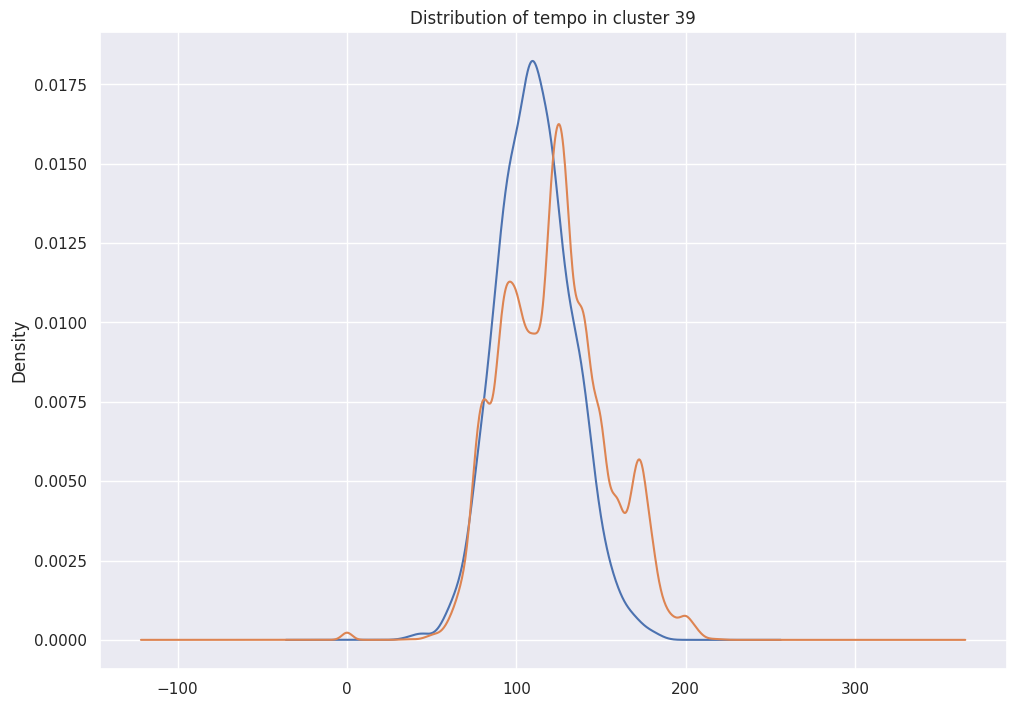

In [23]:
# prompt: Analyze cluster 39. Extract some examples. use the trackid to create SPOTIFY URLS to listen the song, show the genre fecuency table and the distribution of the variables.

import matplotlib.pyplot as plt
cluster_2 = df_with_clusters[df_with_clusters['cluster'] == 2]

# Extract some examples
examples = cluster_2.sample(5)
print("Examples of songs in cluster 39:")
for i, row in examples.iterrows():
  track_id = row['track_id']
  title = row['track_name']
  artist = row['artists']
  url = f"https://open.spotify.com/track/{track_id}"
  print(f"{i+1}. {title} by {artist} ({url})")

# Show the genre frequency table
genre_counts = cluster_2['track_genre'].value_counts()
print("\nGenre frequency table:")
print(genre_counts)

# Show the distribution of the variables
for variable in prop_acusticas:
  plt.figure()
  cluster_2[variable].plot(kind='kde')
  df[variable].plot(kind='kde')
  plt.title(f"Distribution of {variable} in cluster 39")
  plt.show()

In [24]:
centroide = kmeans.cluster_centers_[39,:]
centroide

array([-0.95848369, -0.57483938,  0.28176907, -1.08028441, -0.49968391,
       -0.2880275 ,  1.34801946, -0.4871456 , -0.21006413,  0.68485332,
       -0.30552962])

In [25]:
df_acust

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
track_id,,,,,,,,,,,
5SuOikwiRyPMVoIQDJUgSV,1.929761,0.013605,0.642881,-0.678152,0.334867,0.492194,-0.874040,-0.534513,0.722465,0.933030,-1.134271
4qPNDBW1i3p13qLCt0Ki3A,1.056303,-0.705322,-0.807103,-1.829058,-1.678624,-0.097887,1.764207,-0.534499,-0.595180,-0.771760,-1.480544
1iJBSr7s7jYXzM8EGcbK5b,1.153354,-0.162366,-0.705151,-1.076093,-0.238716,-0.280131,-0.348047,-0.534517,-0.513147,-1.331144,-1.518963
6lfxq3CG4xtTiEg7opyCyx,1.832710,-0.241243,-1.679359,-2.244164,-1.924336,-0.451758,1.707999,-0.534298,-0.436242,-1.243621,1.981223
5vjLSffimiIP26QG5WcN2K,2.366491,-0.268561,0.314369,-0.748377,-0.228542,-0.307556,0.418163,-0.534517,-0.687979,-1.152293,-0.070614
...,...,...,...,...,...,...,...,...,...,...,...
2C3TZjDRiAzdyViavDJ217,-0.593564,1.382462,-2.211775,-1.559863,-1.516992,-0.399562,0.924039,2.334964,-0.670547,-1.658783,0.130150
1hIz5L4IB9hN3WRYPOCGPw,-0.545038,1.382471,-2.200447,-2.020225,-1.886519,-0.418141,1.971291,2.483385,-0.574672,-1.654597,-1.223197
6x8ZfSoqDjuNa5SVP5QjvX,-0.545038,0.375480,0.376673,-1.193134,-0.461584,-0.401332,1.595582,-0.534517,-0.682852,1.039579,0.342104


In [26]:
distancias = (((df_acust - centroide)**2).sum(axis=1))**0.5

In [27]:
df["distancia_al_39"] = distancias.reset_index()[0]

In [28]:
df.sort_values("distancia_al_39")

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,distancia_al_39
46545,1WxNZuHeWkoX1P0BSb3FHZ,Paul Elstak;Re-Style,Offensive Remix Pack,Handz Up - Re-Style Remix,19,241371,False,0.482,0.922,11,...,0.0745,0.02890,0.076700,0.2320,0.1230,175.058,4,happy,18,0.471606
46262,48LsRSuAR1C4FcXeqlZxJa,Technikore;Suae;KYRK,Breaking Free,Breaking Free,20,214506,False,0.565,0.950,9,...,0.1250,0.05700,0.000186,0.2440,0.5080,164.924,4,happy,20,0.553656
46712,1p4a0vI4yz5CYsBobPRAbl,Endymion;Eva Blom,Save me (Endymion Remix),Save me - Endymion Remix,18,194805,False,0.294,0.871,1,...,0.0600,0.00615,0.000000,0.6150,0.1540,153.786,4,happy,21,0.605083
46240,3bPhKK9m3nmw67FIcIe8Uw,Hard Creation,I Will Have That Power,I Will Have That Power,23,378949,False,0.725,0.892,7,...,0.2880,0.35100,0.015500,0.1770,0.1760,170.060,4,happy,1,0.627437
46605,5A75dQjETCrhoaXRjRndC2,Darren Styles;Re-Con;Matthew Steeper,Rest Of Your Life,Rest Of Your Life - Original Mix,18,295235,False,0.489,0.912,11,...,0.2030,0.00106,0.022800,0.0929,0.2800,169.961,4,happy,18,0.656868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,...,0.0422,0.64000,0.928000,0.0863,0.0339,125.995,5,world-music,24,NaN
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,...,0.0401,0.99400,0.976000,0.1050,0.0350,85.239,4,world-music,24,NaN
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,...,0.0420,0.86700,0.000000,0.0839,0.7430,132.378,4,world-music,39,NaN
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,...,0.0297,0.38100,0.000000,0.2700,0.4130,135.960,4,world-music,15,NaN


In [29]:
trackids = list(distancias.sort_values()[:20].index)
trackids

['1RerBSxp75Ww7NMslxxThk',
 '5uFbqLSIBeHog8l3AK03WY',
 '6o24Ba3cyNNC0RqBRLCEU1',
 '7DEyLVvbGS5NtNI47rCORw',
 '5q4M634dPUaEoTWBkSKdsd',
 '1cQI15E52Yqrg7r2Kp2Fzu',
 '1e5iF54aarmziV3jU2e83H',
 '7Gk5Fhjn6vmUXzCtdS1HiK',
 '044dqTF55nTnbezQoNZLKO',
 '69N3FOvnYWRZ7CZxQRJGnY',
 '3EikJrAwjdVTTreMfVpH3G',
 '1Oe7t3gFbWsN7hngBjd4cY',
 '5PNpWZAuYZ3q8rvfEMOOMU',
 '0nVeWWMHo1VHUrOBi7saXD',
 '4v3JQA0eIHqDSMQHa4JMn0',
 '63G6T1RRSSB9Q3vK4tPtNR',
 '3sQ4frj4EV20sLuDjPHscg',
 '6ObewuQSNkFe4IjKjb4IPy',
 '6UwVUhHjGfPTfqhFxwFB5t',
 '4s2Yi4FUpvfl9Hrr8n7TEu']

# Ejercicio 2: Número óptimo de clusters

Vamos a intentar definir un número óptimo de clusters para este dataset.

- Antes de comentar ¿Cuántos crees que deberían ser?
- Usa el método del codo para intentar encontrar un número

Tras realizarlo

- Reflexiona ¿qué ha ocurrido?

In [30]:
from sklearn.cluster import KMeans

def elbow(df, min_=1, max_=20):
  resultados = []

  for i in range(min_, max_):
      kmeans = KMeans(n_clusters=i)
      kmeans.fit(df)
      resultados.append([i, kmeans.inertia_])

  return pd.DataFrame(resultados, columns=["clusters", "inertia"])

<Axes: xlabel='clusters', ylabel='inertia'>

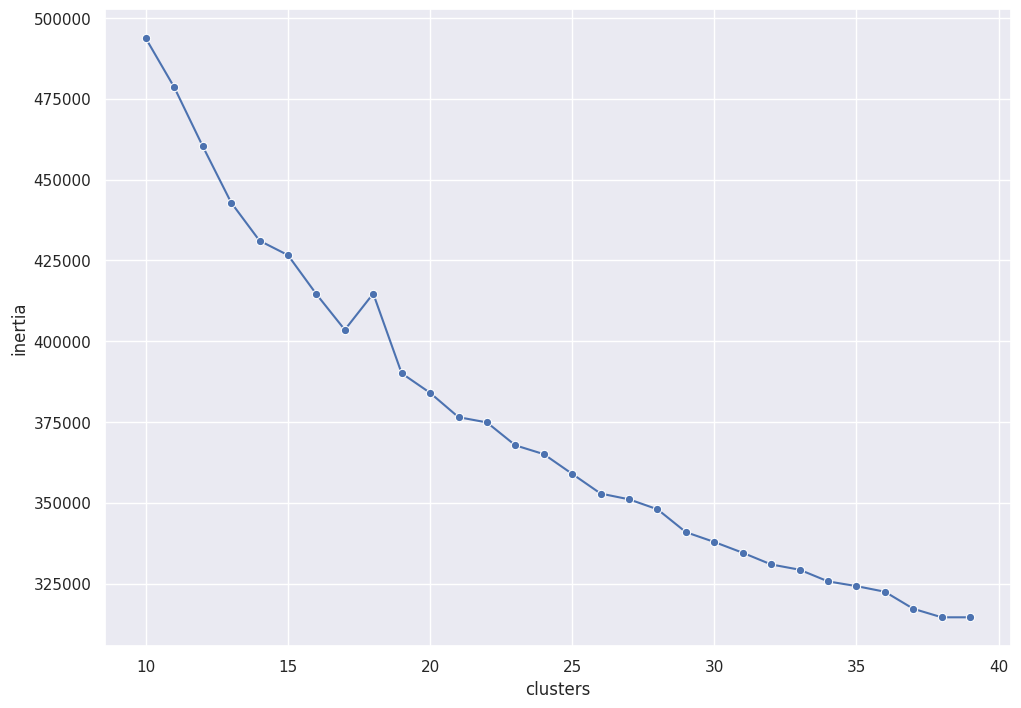

In [31]:
sns.lineplot(data=elbow(df_acust, min_=10, max_=40), x="clusters", y="inertia", marker="o")

# Ejercicio 3: Nuestro Daily Mix

Vamos a crear nuestro propio "Daily Mix": listas de música homogéneas

- ¿Cuántos clusters haremos?
- ¿Cuál es la longitud ideal de una playlist?
- ¿Creéis que es así como lo hace Spotify?

In [32]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN()
dbscan.fit(df_acust)

DBSCAN()

In [33]:
labels = dbscan.labels_
labels

array([-1, -1, -1, ..., -1, -1, -1])

In [34]:
# Conteo
pd.Series(labels).value_counts()

,count
-1,84916
3,267
20,208
63,188
57,97
...,...
429,4
61,4
337,4
281,4


In [35]:
cluster_452 = df[df.cluster == 452]

In [36]:
cluster_452.sort_values("popularity", ascending=False)[:10]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,distancia_al_39


In [37]:
cluster_5.sort_values("popularity", ascending=False)[10:20]

NameError: name 'cluster_5' is not defined

# Ejercicio 4: Usando la IA :)

Haz un cluster jerárquico. Usa la IA del colab para crearlo.

In [38]:
# prompt: Create a hierarquical cluster with df_norm. Use a subsample of 10k. Plot the result

import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# Create a subsample of 10k
df_subsample = df_acust.sample(n=10000)

# Create the hierarchical clustering model
model = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None)

# Fit the model to the data
model.fit(df_subsample)

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

In [39]:
model.children_

array([[ 4500,  6738],
       [ 2587,  6927],
       [ 2108,  7516],
       ...,
       [19980, 19990],
       [19989, 19995],
       [19996, 19997]])

In [40]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


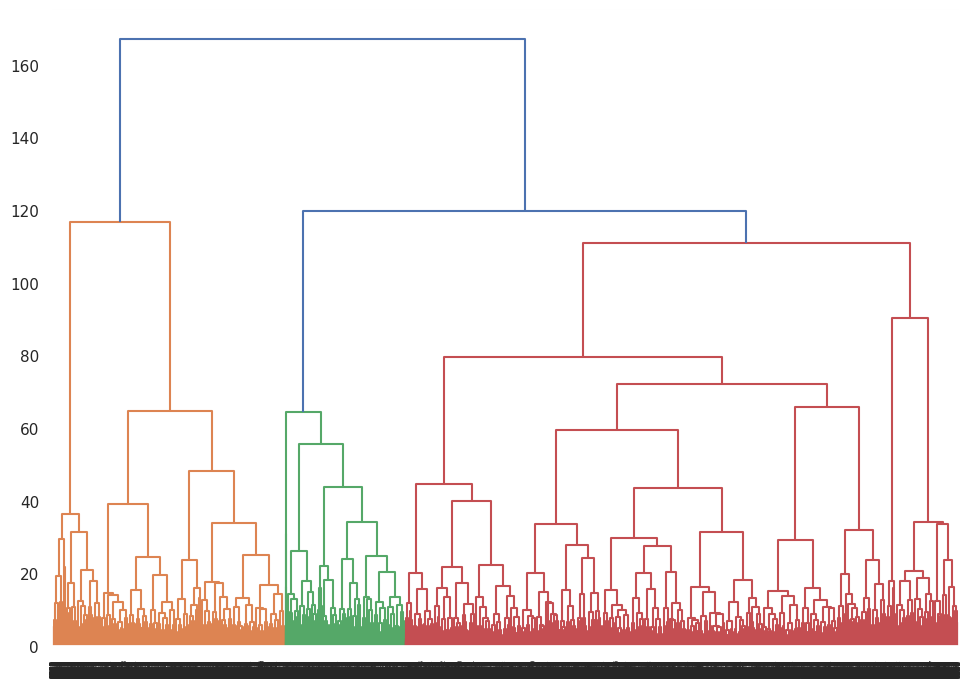

In [41]:
plot_dendrogram(model)

# Ejercicio 5: Usando la IA de forma "avanzada"

Es común pensar que la IA para DS sólo es escribir código. Nada más lejos de la verdad.

Vamos a pedirle a la IA que nos genere el nombre de los clusters que hemos creado:

1. Para cada cluster extraemos 20 canciones con sus títulos, artistas y género.
2. Para usar canciones "conocidas por la IA" vamos a elegir 20 canciones al azar entre las más populares del cluster
3. Después preguntaremos a OpenAI que nos de un nombre del cluster con esas 20 canciones.

In [42]:
!pip install -q openai

In [43]:
from openai import OpenAI

your_api_key = ""

def ask_gpt(prompt):
  # Dejará de funcionar al acabar la clase. Si quieres probar. Crea tu
  # propia API Key en OpenAI
  client = OpenAI(api_key=your_api_key)

  response = client.chat.completions.create(
    model="gpt-4-turbo",
    messages=[
      {"role": "user", "content": prompt}
    ]

    )
  return response.choices[0].message.content

In [44]:
ask_gpt("Hola")

AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [45]:
# Paso 1: obtén las 20 canciones de un cluster.
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=50)
kmeans.fit(df_acust)
df_with_clusters = df
df_with_clusters["cluster"] = kmeans.labels_

In [46]:
top = df_with_clusters.query("cluster == 39").sort_values("popularity", ascending=False)[:20]
top

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,distancia_al_39
91110,62yJjFtgkhUrXktIoSjgP2,Imagine Dragons,Night Visions,Radioactive,80,186813,False,0.448,0.784,9,...,0.0627,0.106000,0.000108,0.668,0.236,136.245,4,rock,39,NaN
56553,1ixbwbeBi5ufN4noUKmW5a,M.I.A.,Kala,Paper Planes,77,205200,False,0.447,0.848,2,...,0.2220,0.033000,0.000075,0.650,0.485,172.253,4,indie-pop,39,6.095794
3971,6wqJeItl3Vc3az4ZicSQAB,Slipknot,Vol. 3: The Subliminal Verses,Before I Forget,77,278600,False,0.291,0.974,6,...,0.1710,0.017700,0.000005,0.886,0.348,134.724,4,alternative,39,5.386333
103652,4QhWbupniDd44EDtnh2bFJ,Frank Ocean,channel ORANGE,Pyramids,73,592920,True,0.400,0.650,5,...,0.0466,0.011800,0.000076,0.791,0.150,107.989,4,soul,39,NaN
30702,10oKSzRcwbZsog2uq2gb4b,Kx5;deadmau5;Kaskade;Hayla,Escape (feat. Hayla),Escape (feat. Hayla),73,240445,False,0.660,0.799,9,...,0.0719,0.179000,0.000364,0.701,0.148,126.080,4,edm,39,4.912833
71350,6o39Ln9118FKTMbM4BvcEy,Bring Me The Horizon,That's The Spirit,Drown,72,222093,False,0.405,0.940,1,...,0.0844,0.000102,0.000028,0.719,0.240,143.126,4,metal,39,2.550858
33366,1yKAqZoi8xWGLCf5vajroL,My Chemical Romance,Three Cheers for Sweet Revenge,The Ghost of You,70,194253,False,0.202,0.886,11,...,0.0816,0.028600,0.000000,0.643,0.192,145.781,4,emo,39,5.102787
30942,7grzdNt3eQRiBC70GksRp1,Afrojack;R3HAB;Au/Ra,Worlds On Fire (with R3HAB & Au/Ra),Worlds On Fire (with R3HAB & Au/Ra),69,174193,False,0.621,0.756,5,...,0.1140,0.075200,0.000001,0.650,0.265,124.039,4,edm,39,2.271714
30819,3QqHt507QJZCzluEYsnv4u,Swedish House Mafia;Ty Dolla $ign;070 Shake,Paradise Again,Lifetime (with Ty Dolla $ign & 070 Shake),69,186805,False,0.584,0.718,11,...,0.1260,0.020500,0.000003,0.906,0.155,99.841,4,edm,39,2.838943
71916,1TEZWG1FdjzDdercCguTwj,Limp Bizkit,Significant Other,Nookie,69,289560,True,0.573,0.929,11,...,0.0820,0.002180,0.072300,0.718,0.284,97.570,4,metal,39,3.335525


In [47]:
top[["track_name", "artists", "track_genre"]].to_dict(orient="records")

[{'track_name': 'Radioactive',
  'artists': 'Imagine Dragons',
  'track_genre': 'rock'},
 {'track_name': 'Paper Planes',
  'artists': 'M.I.A.',
  'track_genre': 'indie-pop'},
 {'track_name': 'Before I Forget',
  'artists': 'Slipknot',
  'track_genre': 'alternative'},
 {'track_name': 'Pyramids', 'artists': 'Frank Ocean', 'track_genre': 'soul'},
 {'track_name': 'Escape (feat. Hayla)',
  'artists': 'Kx5;deadmau5;Kaskade;Hayla',
  'track_genre': 'edm'},
 {'track_name': 'Drown',
  'artists': 'Bring Me The Horizon',
  'track_genre': 'metal'},
 {'track_name': 'The Ghost of You',
  'artists': 'My Chemical Romance',
  'track_genre': 'emo'},
 {'track_name': 'Worlds On Fire (with R3HAB & Au/Ra)',
  'artists': 'Afrojack;R3HAB;Au/Ra',
  'track_genre': 'edm'},
 {'track_name': 'Lifetime (with Ty Dolla $ign & 070 Shake)',
  'artists': 'Swedish House Mafia;Ty Dolla $ign;070 Shake',
  'track_genre': 'edm'},
 {'track_name': 'Nookie', 'artists': 'Limp Bizkit', 'track_genre': 'metal'},
 {'track_name': "Sch

In [49]:
prompt = "Por favor, dada la siguiente lista de canciones:"

for song in top[["track_name", "artists", "track_genre"]].to_dict(orient="records"):
  prompt += f"\n- {song['track_name']} by {song['artists']} ({song['track_genre']})"

prompt = prompt + "\nEscriba un nombre para esta lista:"

In [50]:
ask_gpt(prompt)

AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [51]:
def name_cluster(clusterid):
  """
  Esta función llama a GPT para nombrar el cluster con el id clusterid
  """
  top = df_with_clusters.query("cluster == @clusterid").sort_values("popularity", ascending=False)[:20]

  prompt = "Por favor, dada la siguiente lista de canciones:"
  for song in top[["track_name", "artists", "track_genre"]].to_dict(orient="records"):
    prompt += f"\n- {song['track_name']} by {song['artists']} ({song['track_genre']})"

  prompt += "\nEscriba un nombre para esta lista:"
  return ask_gpt(prompt)

In [52]:
name_cluster(40)

AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [53]:
top = df_with_clusters.query("cluster == 40").sort_values("popularity", ascending=False)[:20]
top

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,distancia_al_39
13002,4h4AEqy0iBbjdlbtWvIx5O,Paul Johnson,Get Get Down,Get Get Down,58,367786,False,0.879,0.950,5,...,0.0746,0.000161,0.8060,0.0714,0.615,126.903,4,chicago-house,40,5.124869
25612,1vCBk33l9HaWp5FOnhSGxk,Donna Summer,I Remember Yesterday,I Feel Love,56,355173,False,0.674,0.711,0,...,0.0423,0.031000,0.6910,0.0925,0.961,126.696,4,disco,40,5.485262
83900,2edcAWwKM7SQajsFGP0edC,deadmau5;Kaskade,I Remember,I Remember,54,593600,False,0.848,0.497,11,...,0.0529,0.020100,0.2970,0.2170,0.615,128.013,4,progressive-house,40,1.955668
110240,22DnBQIIXFPJNRGuNjWlSg,Infected Mushroom,Vicious Delicious,Becoming Insane,54,440266,False,0.654,0.820,2,...,0.0648,0.003680,0.3640,0.1950,0.617,145.002,4,trance,40,NaN
111171,0oeEqyEAavgPfFxDYvjAP6,Massive Attack,Mezzanine,Dissolved Girl,53,366893,False,0.646,0.602,5,...,0.0281,0.035100,0.8190,0.0635,0.662,131.994,4,trip-hop,40,NaN
73324,2rfJqaiKKH2VFzj61oscaa,Niconé;Sascha Braemer;Narra,Romantic Thrills,Caje (Album Edit) - Orginal Version,53,439565,False,0.708,0.735,10,...,0.0604,0.016300,0.6100,0.0993,0.720,122.959,4,minimal-techno,40,3.323360
73065,1IbNYr8ByXsgwGbmOxLBXP,Solomun,Friends,Friends,52,547244,False,0.820,0.505,8,...,0.0356,0.006800,0.5910,0.1280,0.555,119.992,4,minimal-techno,40,2.744018
73474,1pea4MX31SSMy0PeQsme33,Guy Gerber;Albertina;Michael Bibi,Bocat (Michael Bibi Remix),Bocat - Michael Bibi Remix,51,367086,False,0.807,0.766,0,...,0.0783,0.014500,0.7490,0.0812,0.599,126.997,4,minimal-techno,40,3.321590
111922,3AgEOAo3dvkjtsBmeTGRjg,Mr. Scruff;Sneaky,Keep It Unreal (10th Anniversary Analogue Rema...,Get A Move On!,50,454600,False,0.760,0.767,7,...,0.0482,0.003440,0.7590,0.5190,0.816,123.324,4,trip-hop,40,NaN
73227,5pD0jmWSuoCc7hwJLN3VJF,Joris Voorn,Ringo,Ringo,50,410663,False,0.748,0.756,5,...,0.0509,0.035800,0.9080,0.2030,0.717,121.995,4,minimal-techno,40,3.712685


In [54]:
top = df_with_clusters.query("cluster == 39").sort_values("popularity", ascending=False)[:20]
top

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,distancia_al_39
91110,62yJjFtgkhUrXktIoSjgP2,Imagine Dragons,Night Visions,Radioactive,80,186813,False,0.448,0.784,9,...,0.0627,0.106000,0.000108,0.668,0.236,136.245,4,rock,39,NaN
56553,1ixbwbeBi5ufN4noUKmW5a,M.I.A.,Kala,Paper Planes,77,205200,False,0.447,0.848,2,...,0.2220,0.033000,0.000075,0.650,0.485,172.253,4,indie-pop,39,6.095794
3971,6wqJeItl3Vc3az4ZicSQAB,Slipknot,Vol. 3: The Subliminal Verses,Before I Forget,77,278600,False,0.291,0.974,6,...,0.1710,0.017700,0.000005,0.886,0.348,134.724,4,alternative,39,5.386333
103652,4QhWbupniDd44EDtnh2bFJ,Frank Ocean,channel ORANGE,Pyramids,73,592920,True,0.400,0.650,5,...,0.0466,0.011800,0.000076,0.791,0.150,107.989,4,soul,39,NaN
30702,10oKSzRcwbZsog2uq2gb4b,Kx5;deadmau5;Kaskade;Hayla,Escape (feat. Hayla),Escape (feat. Hayla),73,240445,False,0.660,0.799,9,...,0.0719,0.179000,0.000364,0.701,0.148,126.080,4,edm,39,4.912833
71350,6o39Ln9118FKTMbM4BvcEy,Bring Me The Horizon,That's The Spirit,Drown,72,222093,False,0.405,0.940,1,...,0.0844,0.000102,0.000028,0.719,0.240,143.126,4,metal,39,2.550858
33366,1yKAqZoi8xWGLCf5vajroL,My Chemical Romance,Three Cheers for Sweet Revenge,The Ghost of You,70,194253,False,0.202,0.886,11,...,0.0816,0.028600,0.000000,0.643,0.192,145.781,4,emo,39,5.102787
30942,7grzdNt3eQRiBC70GksRp1,Afrojack;R3HAB;Au/Ra,Worlds On Fire (with R3HAB & Au/Ra),Worlds On Fire (with R3HAB & Au/Ra),69,174193,False,0.621,0.756,5,...,0.1140,0.075200,0.000001,0.650,0.265,124.039,4,edm,39,2.271714
30819,3QqHt507QJZCzluEYsnv4u,Swedish House Mafia;Ty Dolla $ign;070 Shake,Paradise Again,Lifetime (with Ty Dolla $ign & 070 Shake),69,186805,False,0.584,0.718,11,...,0.1260,0.020500,0.000003,0.906,0.155,99.841,4,edm,39,2.838943
71916,1TEZWG1FdjzDdercCguTwj,Limp Bizkit,Significant Other,Nookie,69,289560,True,0.573,0.929,11,...,0.0820,0.002180,0.072300,0.718,0.284,97.570,4,metal,39,3.335525


In [ ]:
top[["track_name", "artists", "track_genre"]].to_dict(orient="records")

[{'track_name': 'everything i wanted',
  'artists': 'Billie Eilish',
  'track_genre': 'electro'},
 {'track_name': 'YKWIM?', 'artists': 'Yot Club', 'track_genre': 'indie'},
 {'track_name': 'YKWIM?', 'artists': 'Yot Club', 'track_genre': 'indie-pop'},
 {'track_name': 'Experience',
  'artists': 'Ludovico Einaudi;Daniel Hope;I Virtuosi Italiani',
  'track_genre': 'ambient'},
 {'track_name': 'Experience',
  'artists': 'Ludovico Einaudi;Daniel Hope;I Virtuosi Italiani',
  'track_genre': 'classical'},
 {'track_name': 'i was all over her',
  'artists': 'salvia palth',
  'track_genre': 'indie-pop'},
 {'track_name': 'i was all over her',
  'artists': 'salvia palth',
  'track_genre': 'emo'},
 {'track_name': 'Losing Interest',
  'artists': 'itssvd;Shiloh Dynasty',
  'track_genre': 'chill'},
 {'track_name': 'Blondie',
  'artists': 'Current Joys',
  'track_genre': 'indie-pop'},
 {'track_name': 'Losing Interest',
  'artists': 'itssvd;Shiloh Dynasty',
  'track_genre': 'sad'},
 {'track_name': 'Anchor',

In [55]:
prompt = "Por favor, dada la siguiente lista de canciones:"
for song in top[["track_name", "artists", "track_genre"]].to_dict(orient="records"):
  prompt += f"\n- {song['track_name']} by {song['artists']} ({song['track_genre']})"

prompt += "\nEscriba un nombre para esta lista:"

In [56]:
ask_gpt(prompt)

AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [57]:

def name_cluster(clusterid):
  top = df_with_clusters.query("cluster == @clusterid").sort_values("popularity", ascending=False)[:20]
  prompt = "Por favor, dada la siguiente lista de canciones:"
  for song in top[["track_name", "artists", "track_genre"]].to_dict(orient="records"):
    prompt += f"\n- {song['track_name']} by {song['artists']} ({song['track_genre']})"

  prompt += "\nEscriba un nombre para esta lista:"
  return ask_gpt(prompt)

In [58]:
name_cluster(2)

AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [59]:
df_with_clusters.query("cluster == 2").sort_values("popularity", ascending=False)[:10]


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,distancia_al_39
11817,4w6PEs8WP6Uat3lQsjL5Qs,Yusuf / Cat Stevens,The Very Best Of Cat Stevens,The Wind,44,102640,False,0.756,0.181,2,...,0.0435,0.921,0.023500,0.1280,0.819,115.741,4,british,2,2.715111
55758,4y2QEmnp3DRgXjdbZfUs3X,Suzonn,Rihaee,Rihaee,43,182482,False,0.767,0.125,5,...,0.0399,0.982,0.000000,0.0938,0.838,145.136,3,indian,2,4.456743
90120,0uIgAmyQYVLQnU2hCULaE3,Paco Cañedo,Paco Cañedo,Un Beso Más (One Last Kiss),43,106026,False,0.576,0.280,10,...,0.0661,0.659,0.000000,0.4180,0.604,133.558,4,rock-n-roll,2,3.036268
84966,2lGujFVgZ3OfWYxdTltdye,Syd Barrett,The Madcap Laughs,Here I Go,42,189066,False,0.468,0.328,9,...,0.0435,0.524,0.000000,0.3440,0.676,128.469,4,psych-rock,2,3.072296
19938,61F4Rp4Kh9jQZxO9B5KDDJ,Cayouche,Un vieux hippy,La chaîne de mon tracteur,41,144240,False,0.603,0.198,2,...,0.0319,0.952,0.000146,0.0999,0.734,98.548,4,country,2,4.556379
12257,5s9jhOJe92zrdZVXoNz7hX,George Lam,真情精選,分分鐘需要你,41,182493,False,0.532,0.413,4,...,0.0418,0.744,0.016600,0.2290,0.798,111.946,4,cantopop,2,3.288162
45036,3KSqeds9xE8rBDt4QEjrLk,Los Tecolines,Los Tecolines: Bolero Romantico,Prisionero Del Mar,41,183771,False,0.711,0.283,4,...,0.0342,0.922,0.049900,0.1450,0.812,128.340,4,guitar,2,4.838025
74745,7CKRzfwesUElQPPtYM7Sv9,Almir Sater,Ensaio,Cabelo Loiro,41,59426,False,0.733,0.297,2,...,0.0543,0.949,0.000001,0.2220,0.963,143.234,4,mpb,2,2.749710
90134,40Jl6RwbLIdXeqFR2HPOBv,Sonora Maracaibo,La Mas Romantica de America,No Dejes de Quererme,41,144979,False,0.547,0.318,0,...,0.0328,0.712,0.000051,0.4210,0.800,108.224,4,rock-n-roll,2,3.780697
90175,0B8uTkOG0jkN1BfK2kaZe1,Mike Laure,Lo Mejor De Mike Laure,Humanidad,40,151974,False,0.664,0.379,9,...,0.0382,0.693,0.000000,0.3140,0.877,122.175,4,rock-n-roll,2,3.792622


# QR Evaluación
